[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__Home__](../README.md)

# Divvy: Bike Sharing Forecast
## Ensemble: Modeling & Validation

__Dataset:__ [Divvy Data](https://divvybikes.com/system-data) \
__Author:__ [Dmitry Luchkin](https://www.linkedin.com/in/dmitry-luchkin/) \
__Date:__ May 2025

> **Attention**
>
> The data utilized in this project were sourced from the official public data provided by Divvy. All analysis, results, and insights presented in this notebook were conducted and formulated by Dmitry Luchkin. I declare that I am not affiliated with Divvy, Lyft, the City of Chicago, or any associated organizations. The views and interpretations expressed herein are solely my own and do not represent the positions or policies of these entities.

### Notebooks <a class="anchor" name='notebooks'></a>

+ [Initial Data Exploration](./01_Divvy_data_exploration.ipynb)
+ [Data Cleaning](./02_Divvy_data_cleaning.ipynb)
+ [Exploratory Data Analysis](./03_Divvy_exploratory_data_analysis.ipynb)
+ [Feature Engineering](./04_Divvy_feature_engineering.ipynb)
+ Modeling & Validation:
  - [XGBoost: Modeling & Validation](./05.1_Divvy_modeling_xgboost.ipynb)
  - [RNN: Modeling & Validation](./05.2_Divvy_modeling_rnn.ipynb)
  - [ARIMAX: Modeling & Validation](./05.3_Divvy_modeling_arimax.ipynb)
  - __[Ensemble: Modeling & Validation](./05.4_Divvy_modeling_ensemble.ipynb)__
+ [Forecasting](./06_Divvy_forecasting.ipynb)

### Import Libraries <a name='import-libraries'></a>

In [1]:
import os 
import sys
import pickle
import warnings

import pandas as pd
import numpy as np
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error
from sktime.split import temporal_train_test_split
from sktime.utils.plotting import plot_series

from pmdarima import auto_arima

warnings.filterwarnings("ignore")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
sys.path.append('../02_scripts/')

# import project code
from utils.plotting import notebook_setup
from utils.plotting.notebook_setup import TRAIN_COLOR, TEST_COLOR, FORECAST_COLOR
from utils.plotting.viz import plot_trips, distplot, check_residuals, plot_window_size
from utils.model.tools import load_dump
from utils.model.ensemble import find_better_ensemble

### Loading Data <a name='loading-data'></a>

In [3]:
train_filename = "../00_data/02_processed/divvy_train.pkl"
test_filename = "../00_data/02_processed/divvy_test.pkl"
train = None
test = None
# load training set
with open(train_filename, 'rb') as f:
        train = pickle.load(f)

# load test set
with open(test_filename, 'rb') as f:
        test = pickle.load(f)

#### Daily total number of bike trips

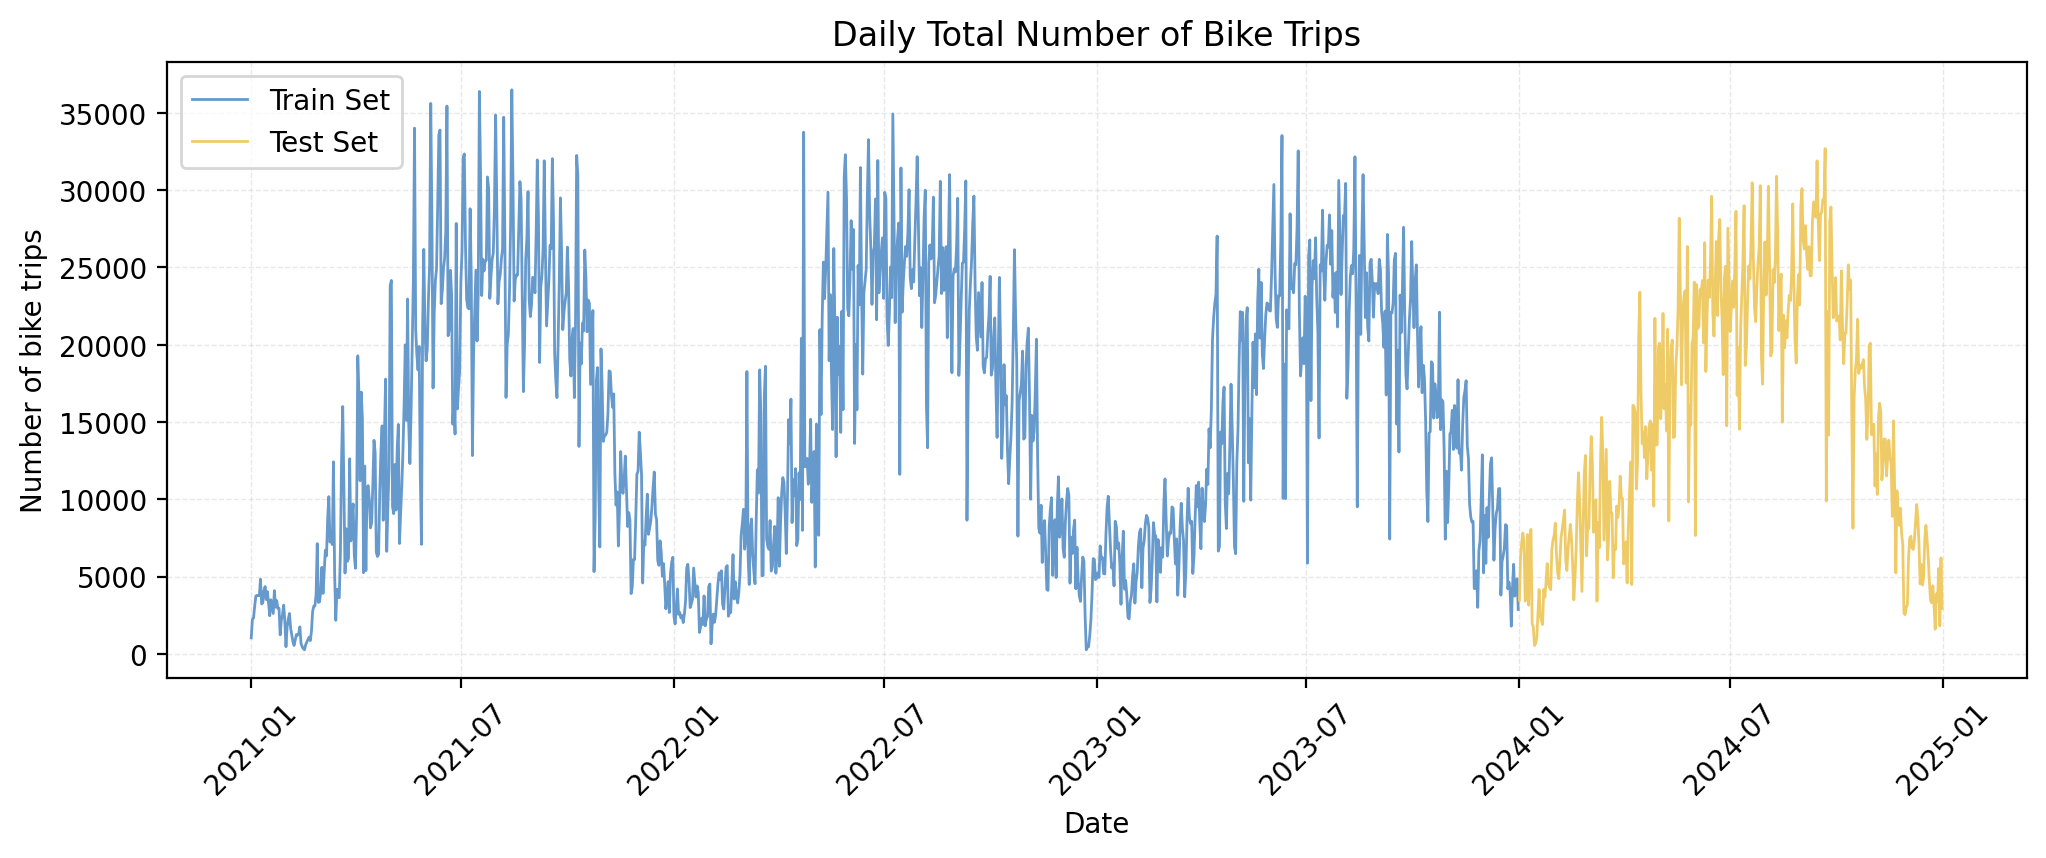

In [4]:
_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], title="Daily Total Number of Bike Trips")
plt.show()

#### Daily sub-total number of bike trips

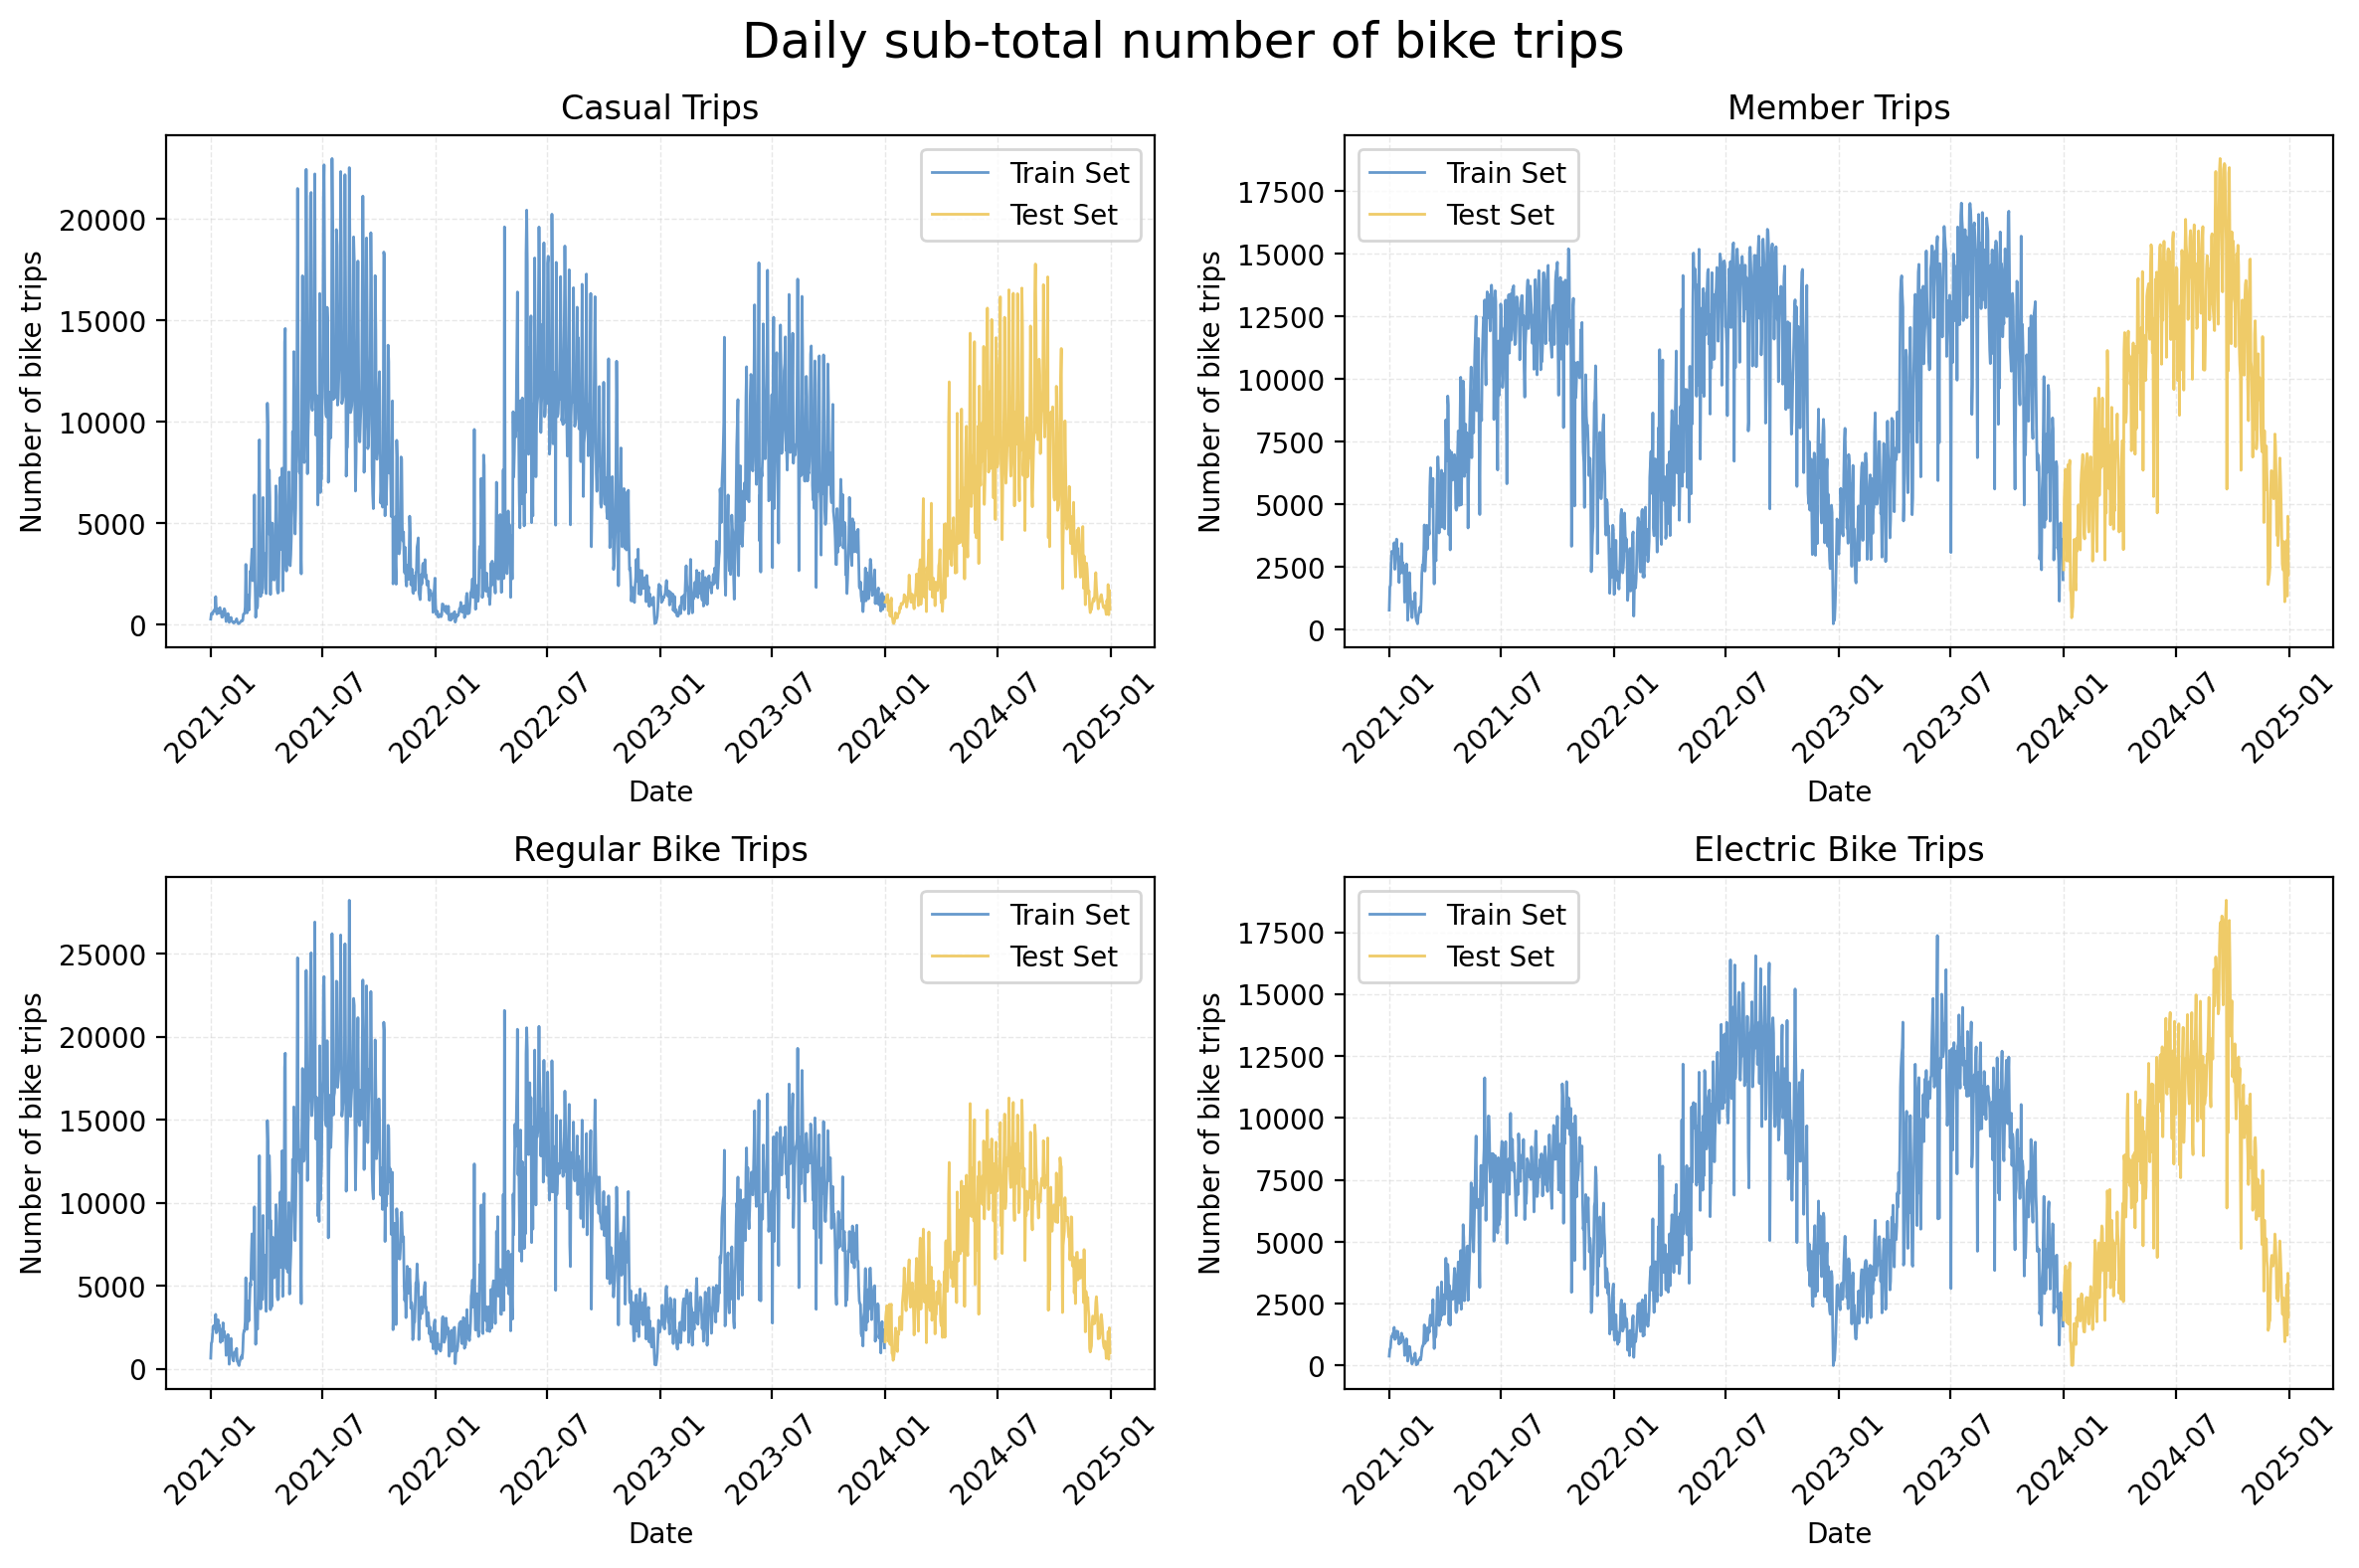

In [5]:
_, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_trips(ax[0, 0], train["casual_total"], test["casual_total"], title="Casual Trips")
plot_trips(ax[0, 1], train["member_total"], test["member_total"], title="Member Trips")
plot_trips(ax[1, 0], train["regular_total"], test["regular_total"], title="Regular Bike Trips")
plot_trips(ax[1, 1], train["electric_total"], test["electric_total"], title="Electric Bike Trips")
plt.suptitle("Daily sub-total number of bike trips", fontsize=18)
plt.tight_layout()
plt.show()

#### Daily number of trips by bike type and user type

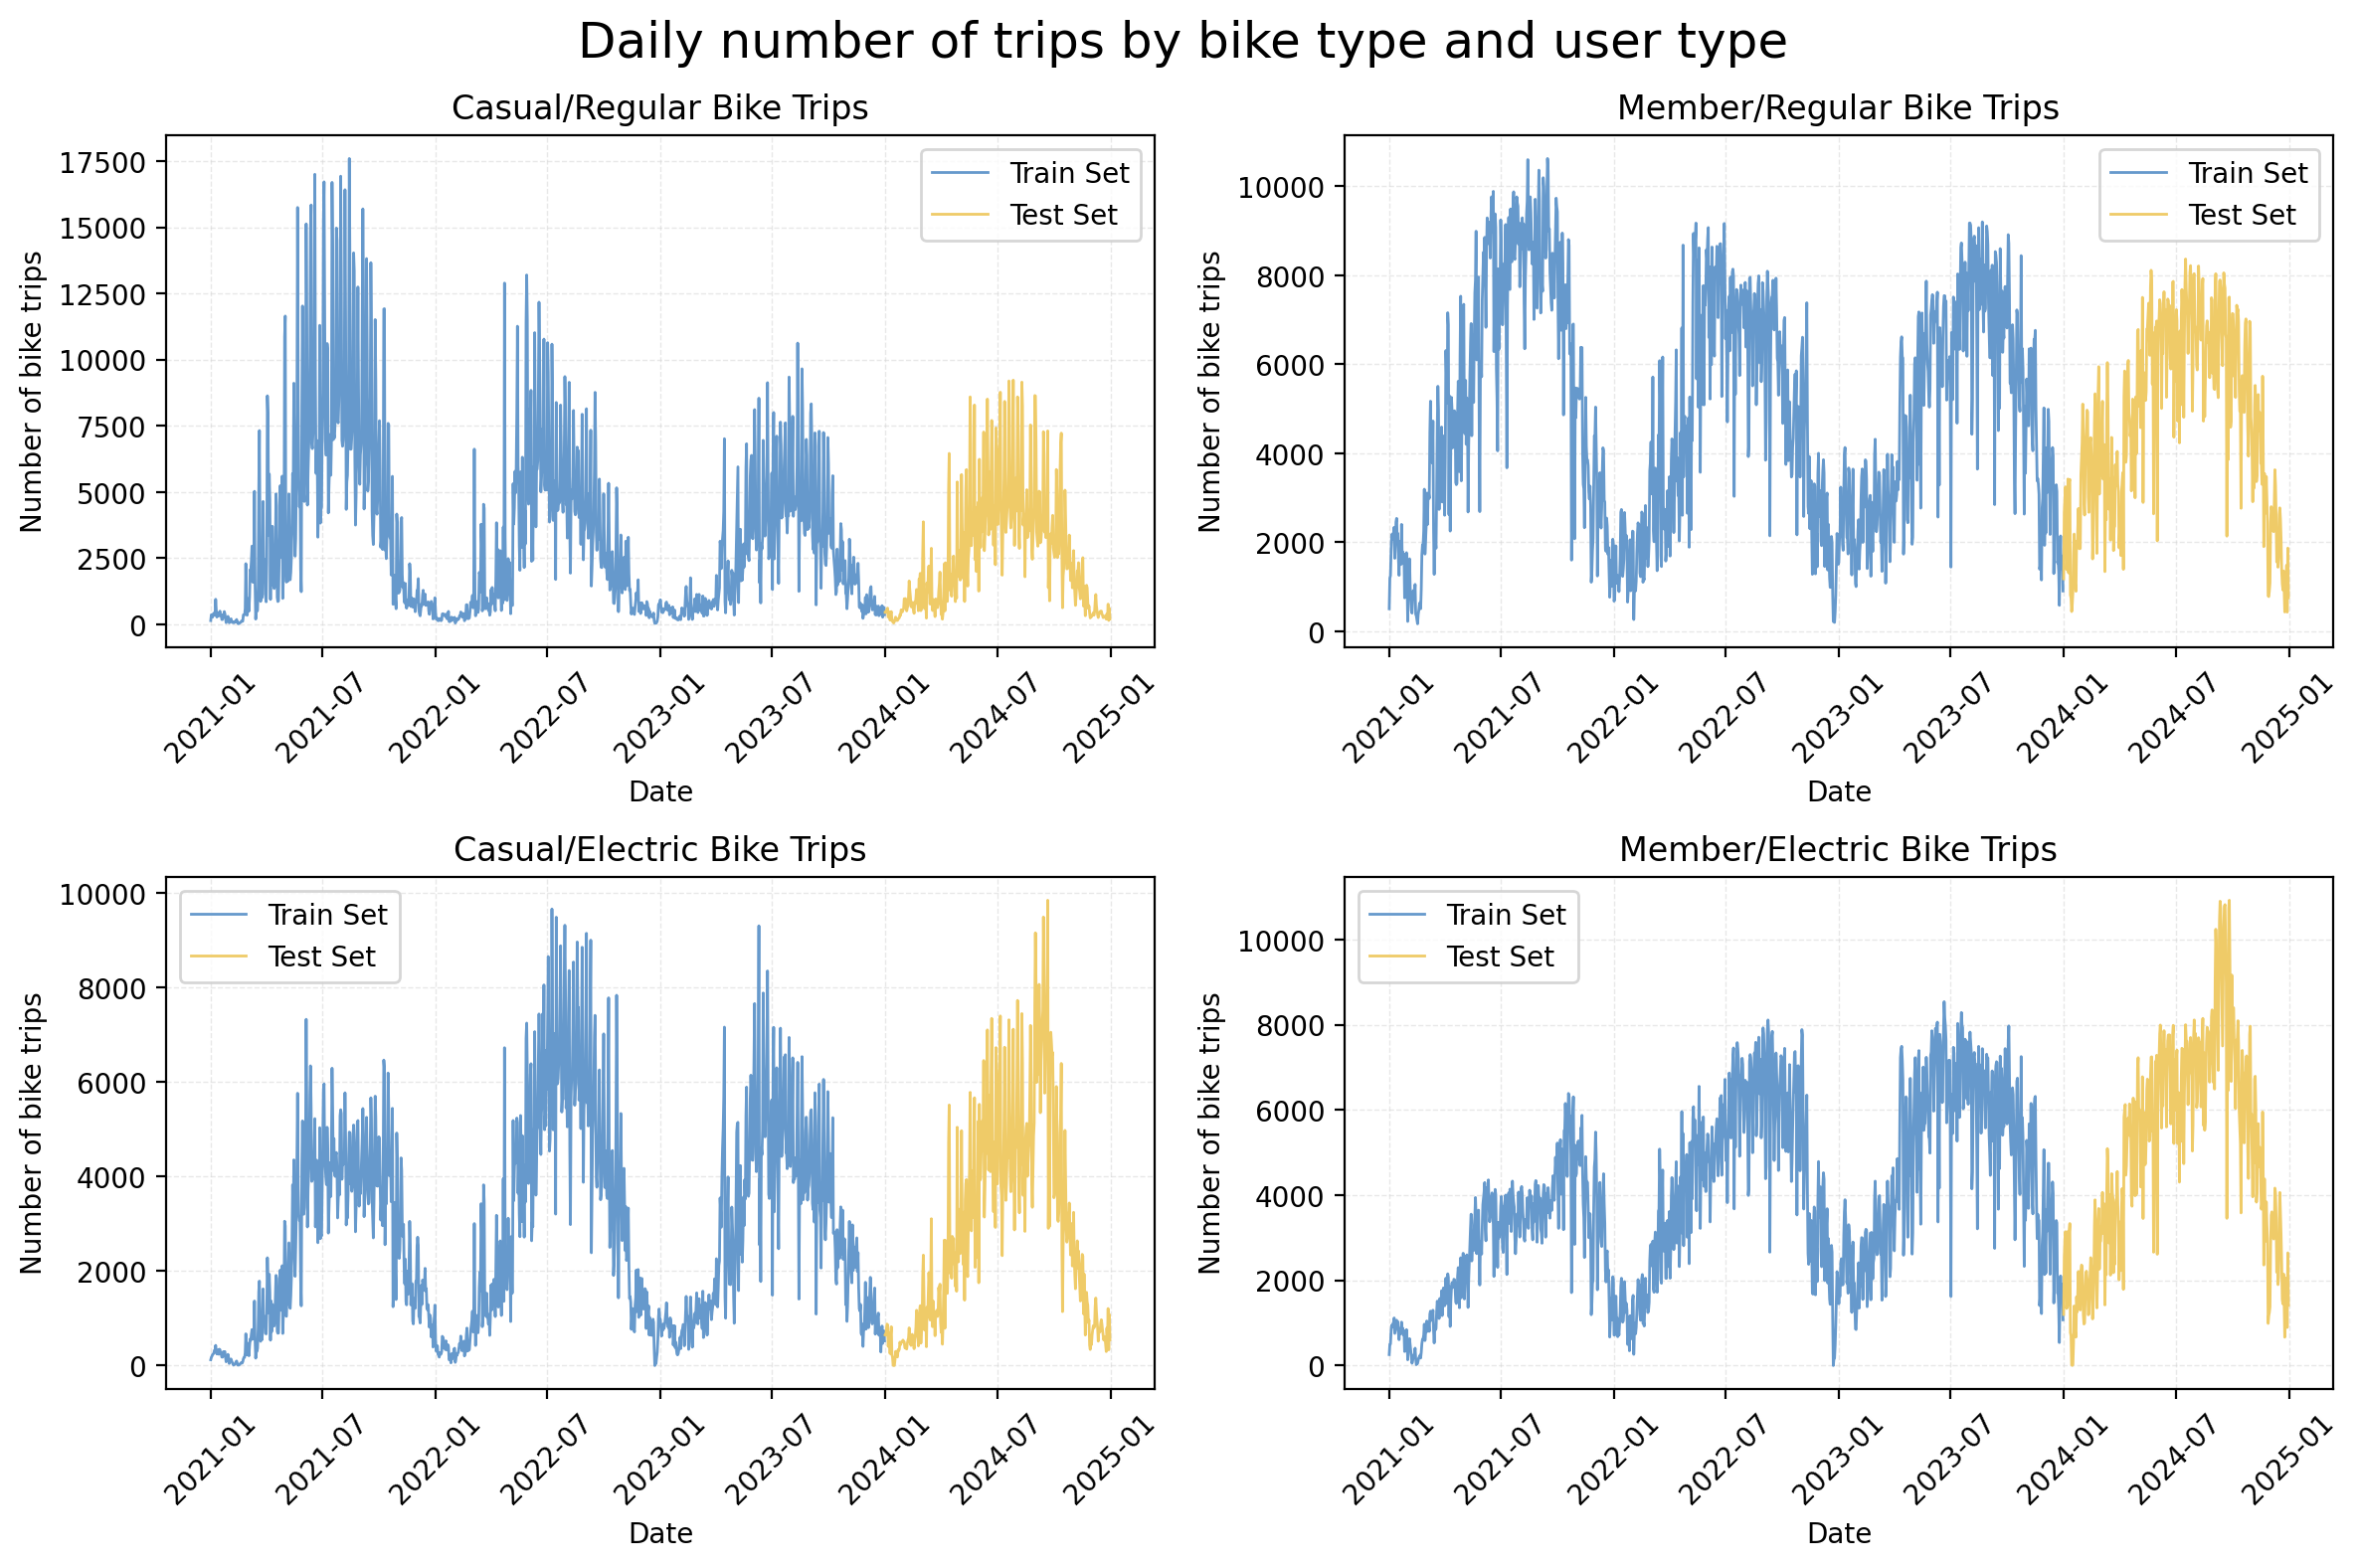

In [6]:
_, ax = plt.subplots(2, 2, figsize=(12, 8))
plot_trips(ax[0, 0], train["casual_regular_bike"], test["casual_regular_bike"], title="Casual/Regular Bike Trips")
plot_trips(ax[0, 1], train["member_regular_bike"], test["member_regular_bike"], title="Member/Regular Bike Trips")
plot_trips(ax[1, 0], train["casual_electric_bike"], test["casual_electric_bike"], title="Casual/Electric Bike Trips")
plot_trips(ax[1, 1], train["member_electric_bike"], test["member_electric_bike"], title="Member/Electric Bike Trips")
plt.suptitle("Daily number of trips by bike type and user type", fontsize=18)
plt.tight_layout()
plt.show()

## Hierarchical Forecasting

Hierarchical forecasting aims to produce forecasts that are both accurate and consistent across levels of the hierarchy.

Two primary approaches are used for hierarchical forecasting:

+ __Bottom-Up Approach__
  The bottom-up method starts by forecasting the most granular (lowest-level) series independently. These forecasts are then aggregated upward to obtain predictions for higher levels in the hierarchy.

+ __Top-Down Approach__
  The top-down method begins by forecasting the top-level (aggregate) series. These forecasts are then disaggregated downward based on historical proportions or predictive models.

In [7]:
ensemble_mae_scores = {
    "bottom-up": {
        "mae": {
            "total_rides": None,
            "regular_total": None,
            "electric_total": None,
            "casual_total": None,
            "member_total": None,
            "casual_regular_bike": None,
            "member_regular_bike": None,
            "casual_electric_bike": None,
            "member_electric_bike": None
            }},
    "top-down": {
        "mae":{
            "total_rides": None,
            "regular_total": None,
            "electric_total": None,
            "casual_total": None,
            "member_total": None,
            "casual_regular_bike": None,
            "member_regular_bike": None,
            "casual_electric_bike": None,
            "member_electric_bike": None
            }}
}

#### Top-Down

![Top-Down Approach](./00_images/top_down.png)

In [8]:
# xgboost dump
xgboost_models_dump = load_dump("../03_models/01_xgboost/xgboost_models_dump.pkl")
# rnn dump
rnn_models_dump = load_dump("../03_models/02_rnn/rnn_models_dump.pkl")
# harimax dump
harimax_models_dump = load_dump("../03_models/03_arimax/arimax_models_dump.pkl")

In [9]:
xgboost_maes = {}
xgboost_forecasts = {}
for key, item in xgboost_models_dump["xgboost"].items():
    if item["level"] == "bottom":
        xgboost_maes[key] = item["model"]["test_mae"]
        xgboost_forecasts[key] = item["model"]["test_forecast"]
    else:
        xgboost_maes[key] = mean_absolute_error(test[key], item["forecast"])
        xgboost_forecasts[key] = item["forecast"]

In [10]:
rnn_maes = {}
rnn_forecasts = {}
for key, item in rnn_models_dump["rnn"].items():
    rnn_maes[key] = item["mae"]
    rnn_forecasts[key] = item["forecast"]

In [11]:
harimax_maes = {}
harimax_forecasts = {}
for key, item in harimax_models_dump["arimax"].items():
    if item["level"] == "bottom":
        harimax_maes[key] = item["model"]["mae"]
        harimax_forecasts[key] = item["model"]["forecast"]
    else:
        harimax_maes[key] = item["mae"]
        harimax_forecasts[key] = item["forecast"]

In [12]:
maes = pd.DataFrame({"xgboost": xgboost_maes, "rnn": rnn_maes, "harimax": harimax_maes})
forecasts = pd.DataFrame({"xgboost": xgboost_forecasts, "rnn": rnn_forecasts, "harimax": harimax_forecasts})

In [13]:
maes

,xgboost,rnn,harimax
casual_regular_bike,408.0877,494.4156,406.5967
casual_electric_bike,427.7171,498.8242,388.3748
member_regular_bike,454.8271,458.1068,407.0505
member_electric_bike,562.4547,520.0868,423.8279
casual_total,697.8636,903.7900,744.2950
member_total,842.9306,797.7675,740.9927
electric_total,907.1503,953.5711,761.1018
regular_total,746.3969,782.2802,745.0698
total_rides,"1,353.5334","1,524.6052","1,372.9184"


In [14]:
ensemble_total_models, \
ensemble_total_mae, \
ensemble_total_forecast, \
ensemble_total_weights = find_better_ensemble(test, "total_rides", forecasts, maes, True)


Models: ['xgboost']
weights: [1.]
MAE: 1353.5333582143314

Models: ['rnn']
weights: [1.]
MAE: 1524.6052459132802

Models: ['harimax']
weights: [1.]
MAE: 1372.9183628619774

Models: ['xgboost', 'rnn']
weights: [0.55922913 0.44077087]
MAE: 1328.7809147668208

Models: ['xgboost', 'harimax']
weights: [0.50710962 0.49289038]
MAE: 1248.9962622236233

Models: ['rnn', 'harimax']
weights: [0.44779255 0.55220745]
MAE: 1331.2085449945569

Models: ['xgboost', 'rnn', 'harimax']
weights: [0.36230098 0.28555687 0.35214215]
MAE: 1261.8428405678696


                    Models        MAE
0       (xgboost, harimax) 1,248.9963
1  (xgboost, rnn, harimax) 1,261.8428
2           (xgboost, rnn) 1,328.7809
3           (rnn, harimax) 1,331.2085
4               (xgboost,) 1,353.5334
5               (harimax,) 1,372.9184
6                   (rnn,) 1,524.6052


The best ensemble ('xgboost', 'harimax') with MAE = 1248.9962622236233



<Figure size 1200x400 with 0 Axes>

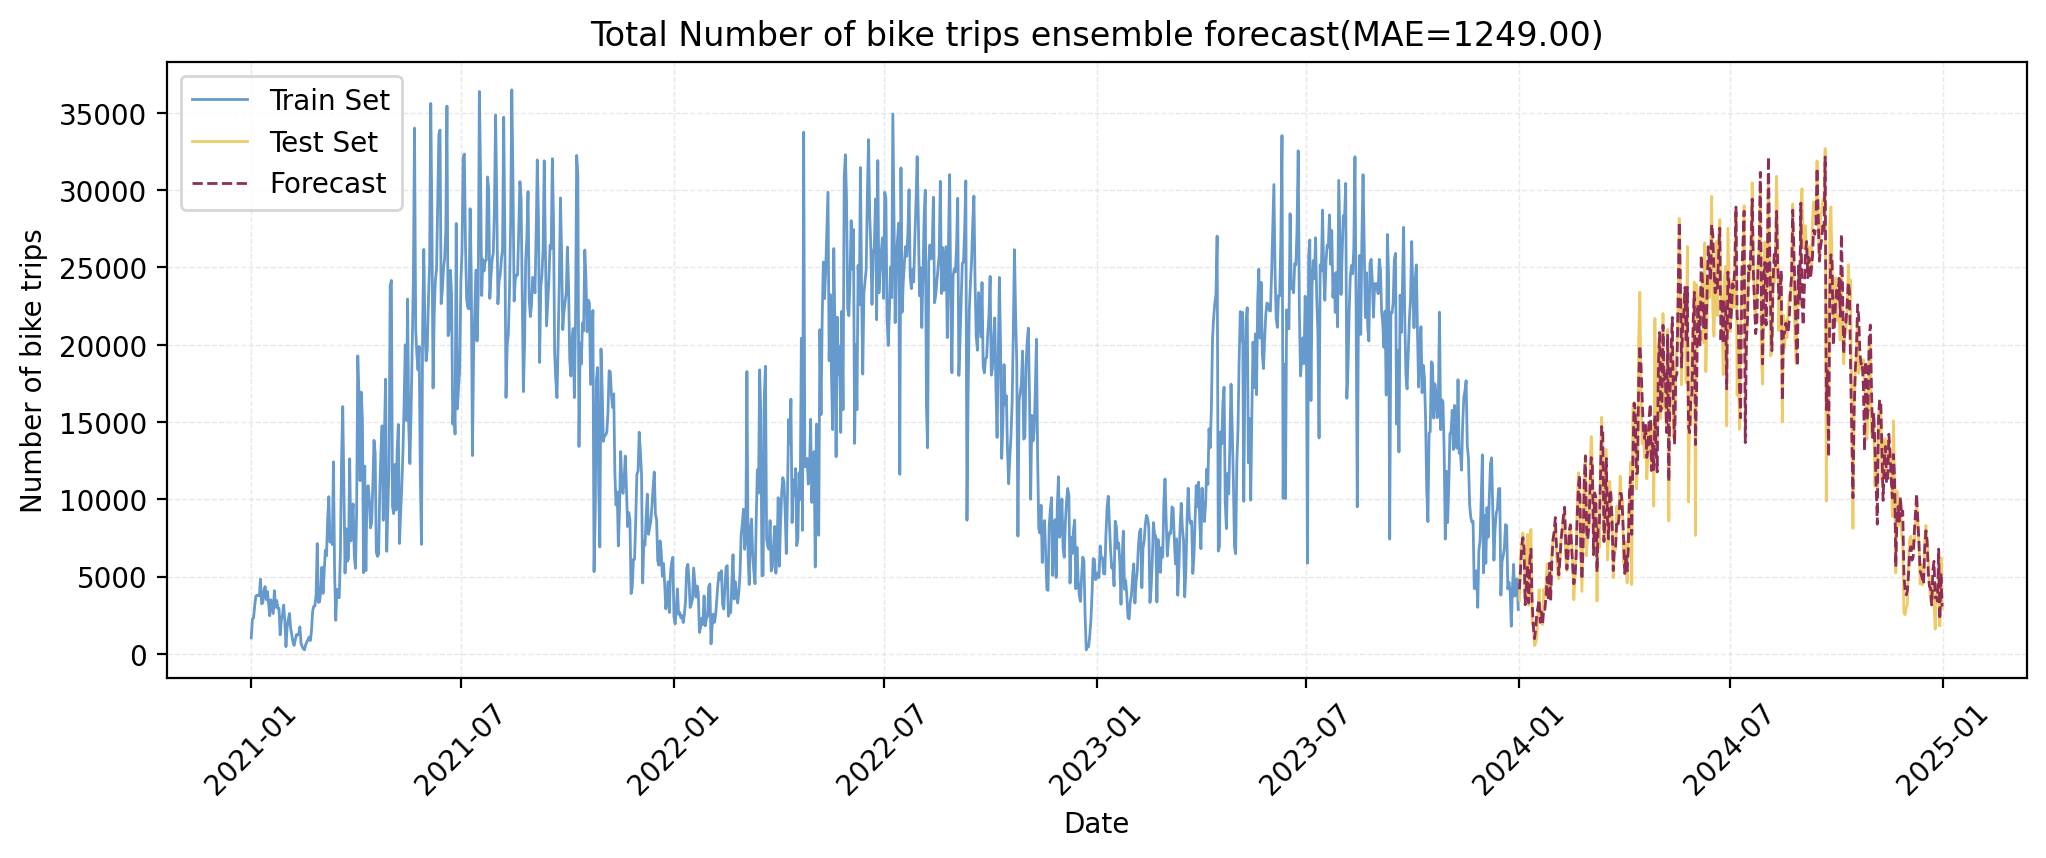

In [15]:
plt.figure(figsize=(12, 4))

_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], 
           forecast=pd.DataFrame(ensemble_total_forecast, index=test.index),
           title=f"Total Number of bike trips ensemble forecast(MAE={ensemble_total_mae:.2f})")

plt.show()

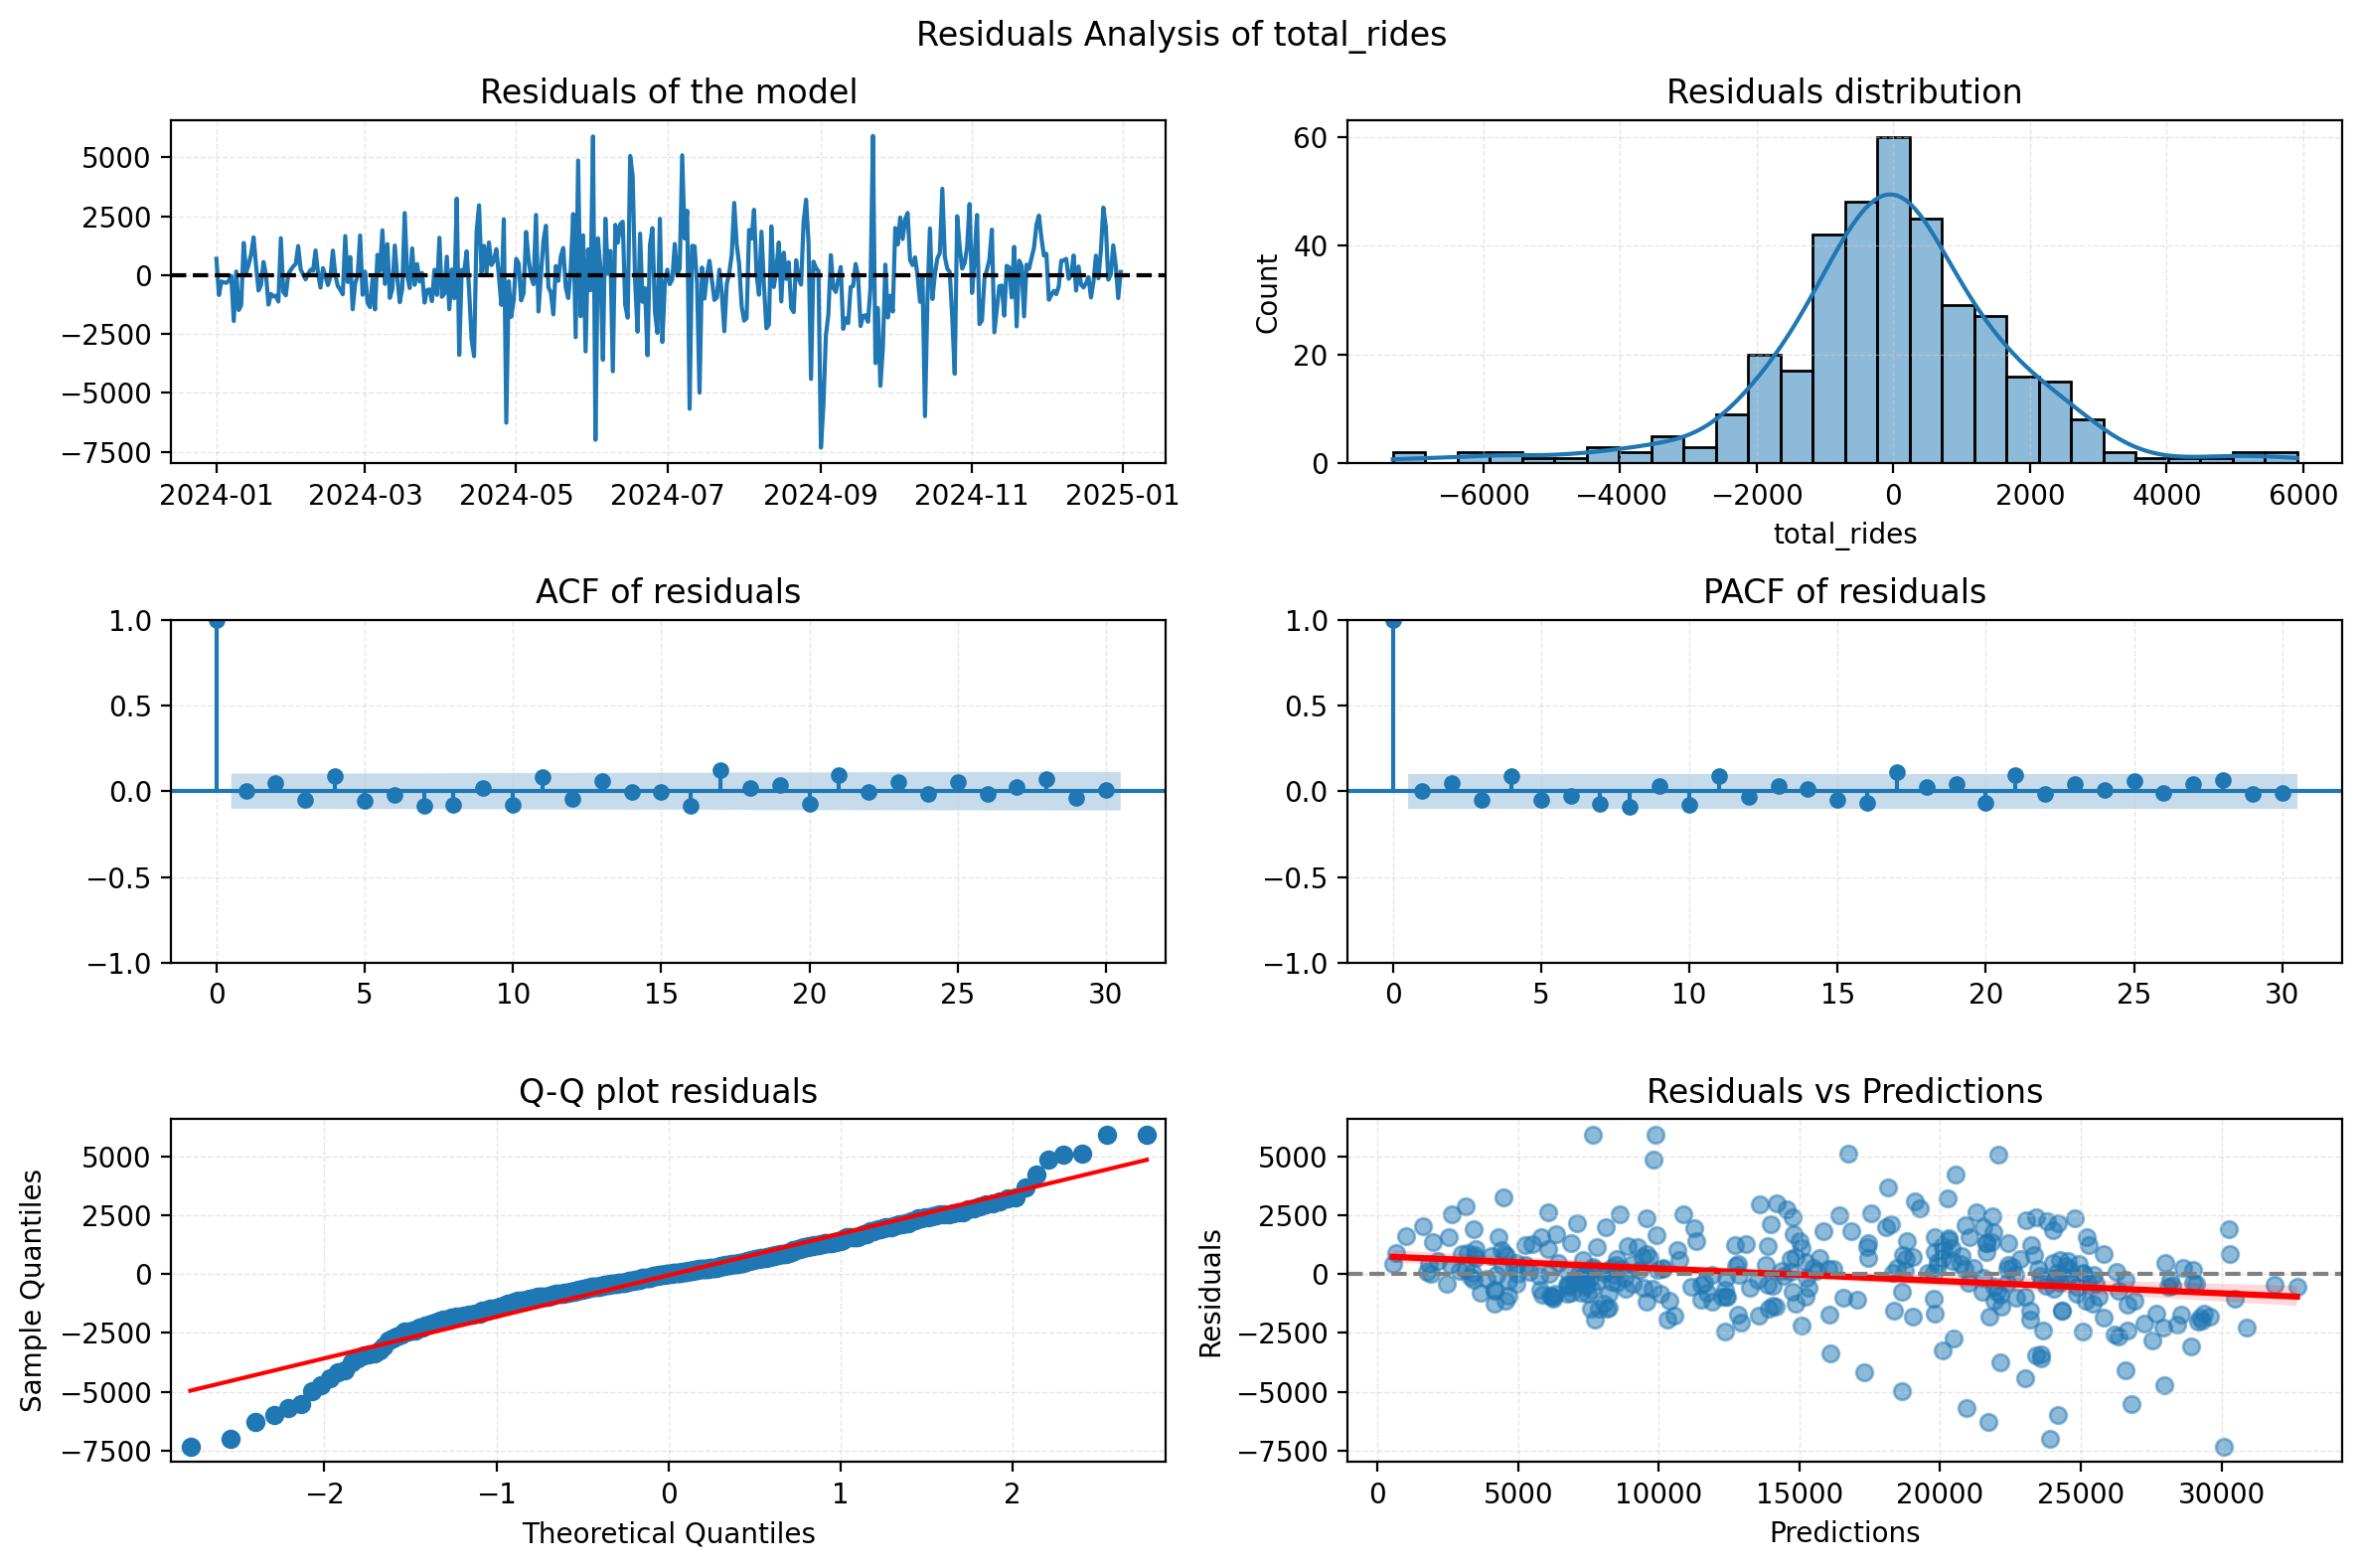


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  13.1617     0.2148
Residuals do not show significant autocorrelation

-- Dickey–Fuller test --
ADF Statistic: -19.06213270905261
p-value: 0.0
Time series is stationary

-- KPSS test --
ADF Statistic: 0.07604427430853726
p-value: 0.1
Time series is stationary


In [16]:
check_residuals(ensemble_total_forecast, test["total_rides"], "total_rides")

In [17]:
ensemble_mae_scores['top-down']['mae']['total_rides'] = ensemble_total_mae

##### Down-level forecast distribution

In [18]:
train_totals = train[['casual_regular_bike', 'member_regular_bike', 'casual_electric_bike',
       'member_electric_bike']].sum()
props =  train_totals / train_totals.sum()
props

casual_regular_bike    0.2164
member_regular_bike    0.3312
casual_electric_bike   0.1902
member_electric_bike   0.2621
dtype: float64

In [19]:
total_forecast = pd.Series(ensemble_total_forecast, index=test.index)
total_forecast.head()

2024-01-01   4,169.6736
2024-01-02   5,447.0906
2024-01-03   6,941.3522
2024-01-04   7,513.9058
2024-01-05   6,838.5358
Freq: D, dtype: float64

In [20]:
td_bottom_forecast = pd.DataFrame({
    node: total_forecast * prop for node, prop in props.items()
})
td_bottom_forecast.head()

,casual_regular_bike,member_regular_bike,casual_electric_bike,member_electric_bike
2024-01-01,902.4556,"1,381.0213",793.1971,"1,092.9996"
2024-01-02,"1,178.9310","1,804.1097","1,036.2001","1,427.8498"
2024-01-03,"1,502.3388","2,299.0182","1,320.4535","1,819.5417"
2024-01-04,"1,626.2583","2,488.6515","1,429.3704","1,969.6256"
2024-01-05,"1,480.0859","2,264.9648","1,300.8948","1,792.5903"


In [21]:
td_casual_regular_mae = mean_absolute_error(test["casual_regular_bike"], td_bottom_forecast["casual_regular_bike"])
td_member_regular_mae = mean_absolute_error(test["member_regular_bike"], td_bottom_forecast["member_regular_bike"])
td_casual_electric_mae = mean_absolute_error(test["casual_electric_bike"], td_bottom_forecast["casual_electric_bike"])
td_member_electric_mae = mean_absolute_error(test["member_electric_bike"], td_bottom_forecast["member_electric_bike"])

In [22]:
ensemble_mae_scores['top-down']['mae']['casual_regular_bike'] = td_casual_regular_mae
ensemble_mae_scores['top-down']['mae']['member_regular_bike'] = td_member_regular_mae
ensemble_mae_scores['top-down']['mae']['casual_electric_bike'] = td_casual_electric_mae
ensemble_mae_scores['top-down']['mae']['member_electric_bike'] = td_member_electric_mae

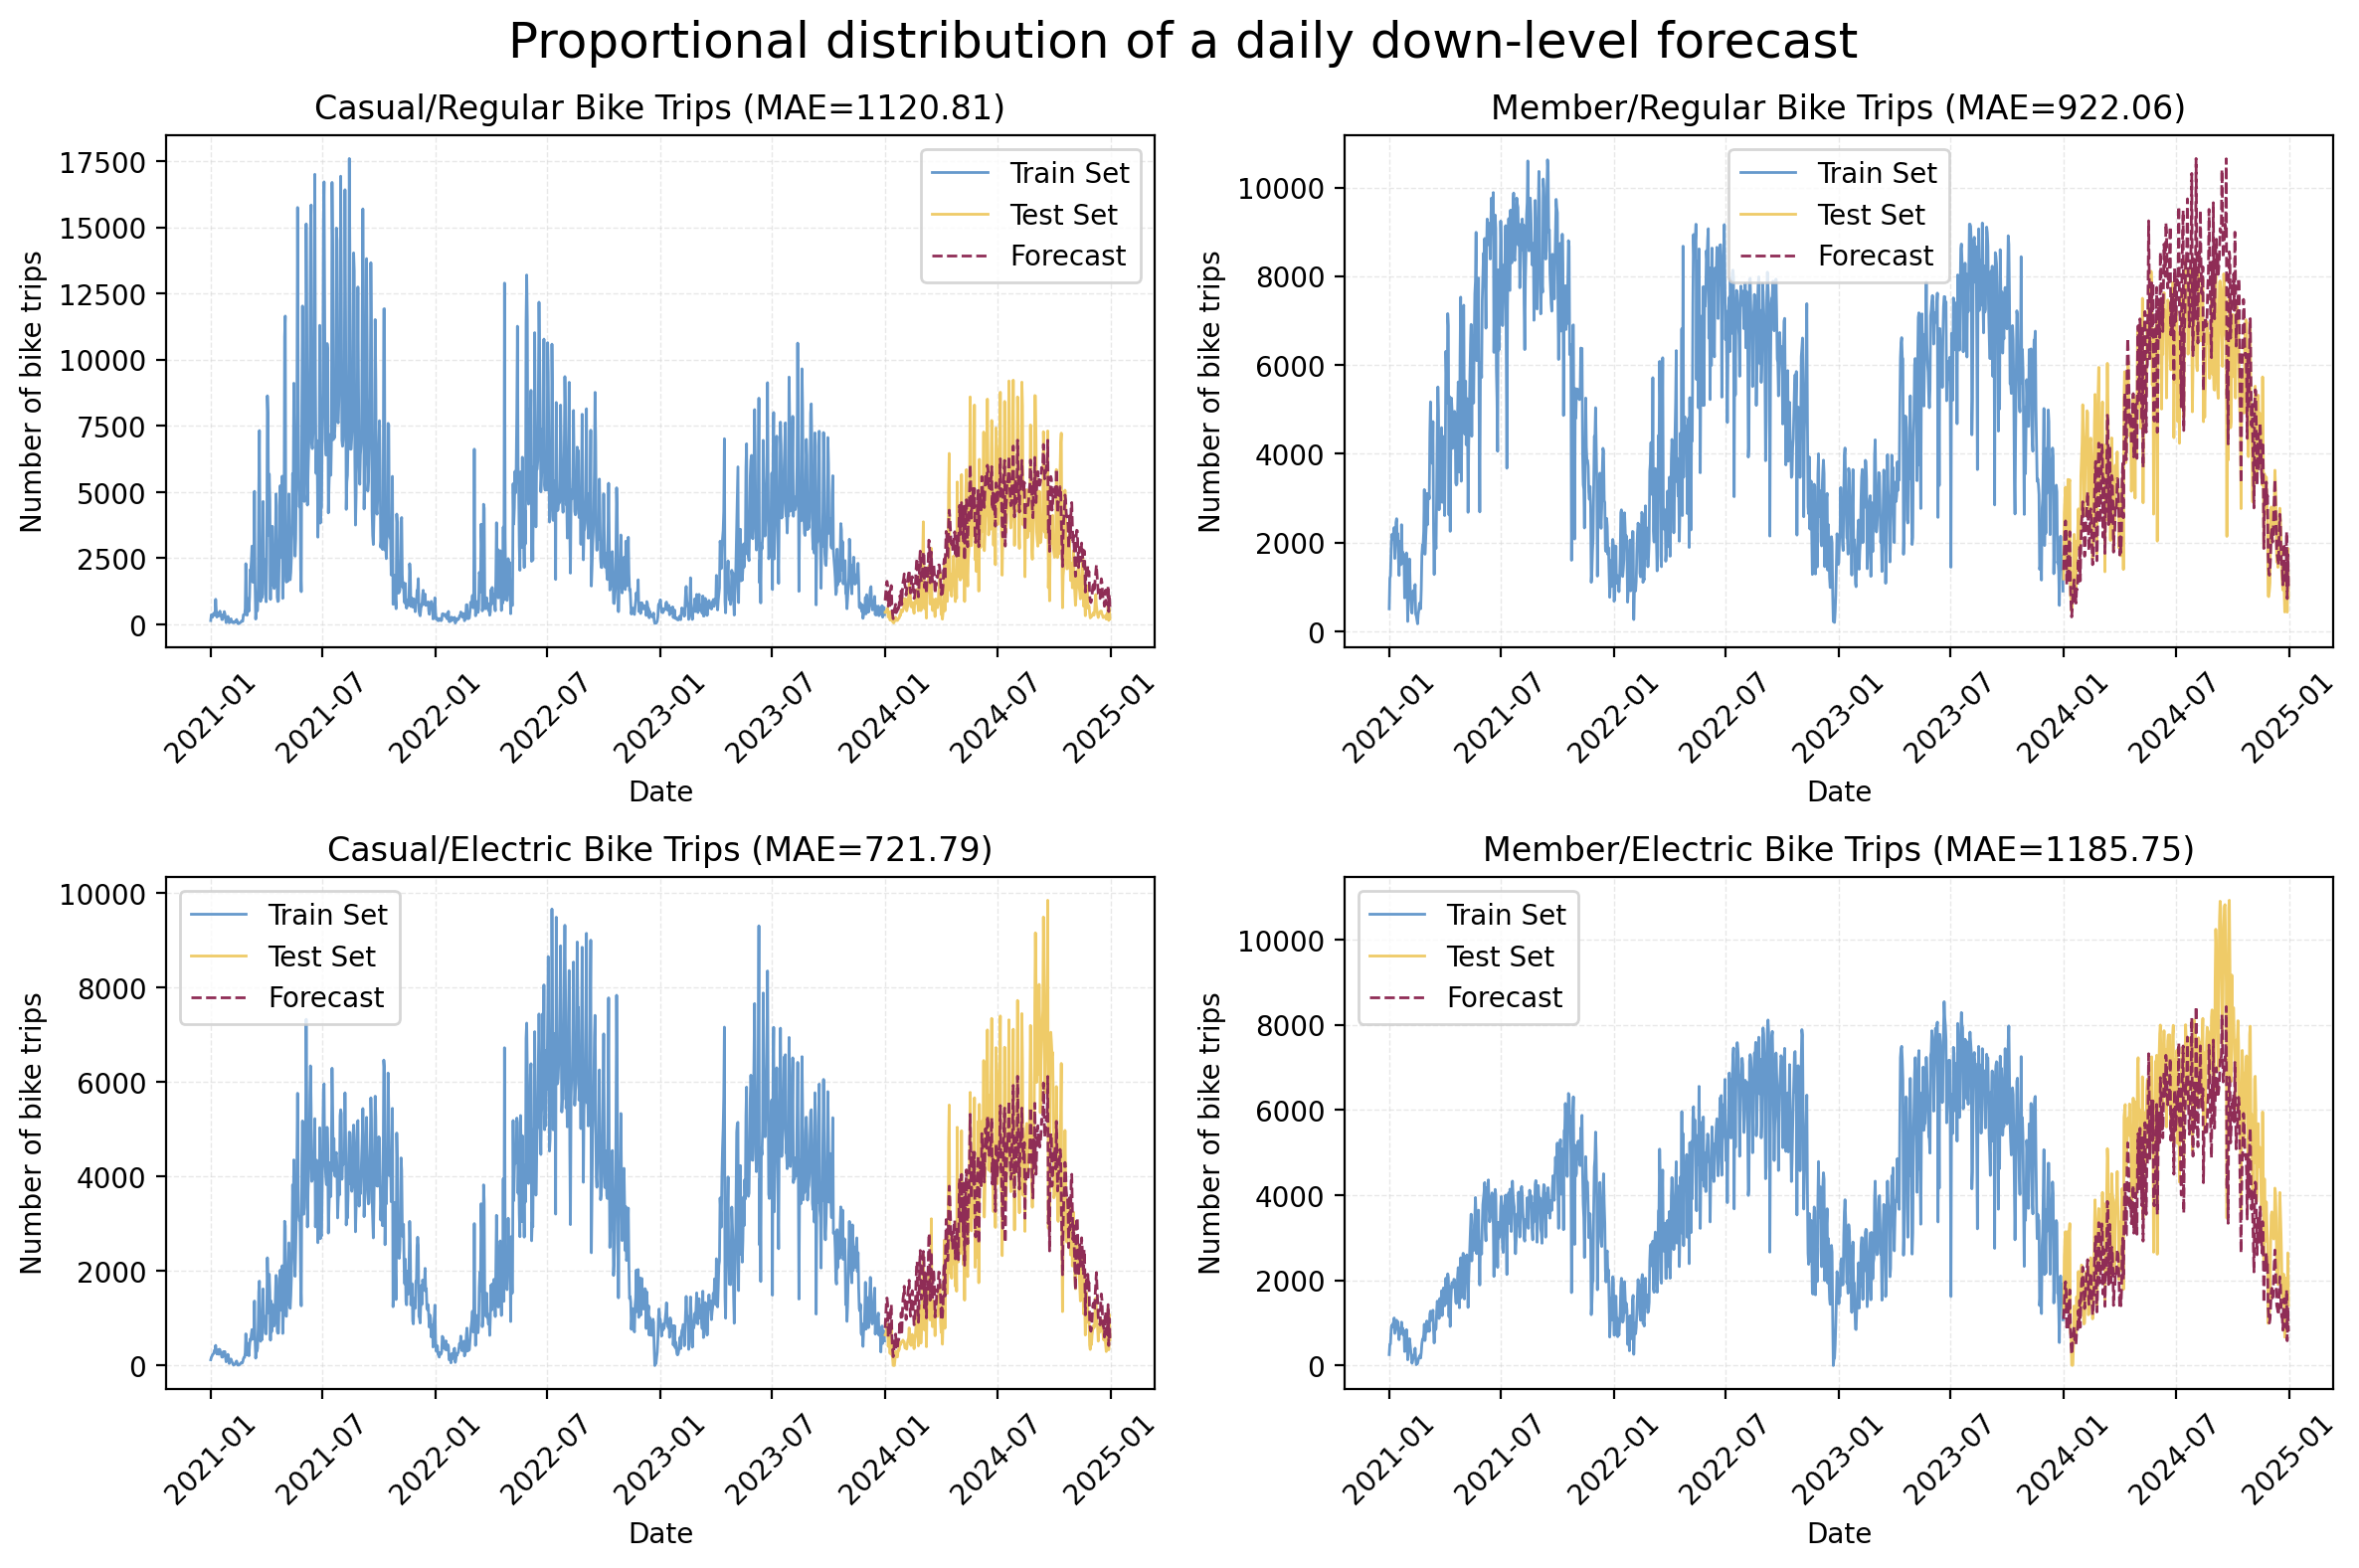

In [23]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

plot_trips(train=train["casual_regular_bike"], 
                    test=test["casual_regular_bike"],
                    forecast=td_bottom_forecast["casual_regular_bike"],
                    title=f"Casual/Regular Bike Trips (MAE={td_casual_regular_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_regular_bike"], 
                    test=test["member_regular_bike"],
                    forecast=td_bottom_forecast["member_regular_bike"],
                    title=f"Member/Regular Bike Trips (MAE={td_member_regular_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["casual_electric_bike"], 
                    test=test["casual_electric_bike"],
                    forecast=td_bottom_forecast["casual_electric_bike"],
                    title=f"Casual/Electric Bike Trips (MAE={td_casual_electric_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["member_electric_bike"], 
                    test=test["member_electric_bike"],
                    forecast=td_bottom_forecast["member_electric_bike"],
                    title=f"Member/Electric Bike Trips (MAE={td_member_electric_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("Proportional distribution of a daily down-level forecast", fontsize=18)
plt.tight_layout()
plt.show()

##### Sub-Total forecast distribution (Bottom-Up for cross-level)

In [24]:
td_bu_casual_total_forecast = td_bottom_forecast["casual_regular_bike"] + \
                                td_bottom_forecast["casual_electric_bike"]
td_bu_member_total_forecast = td_bottom_forecast["member_regular_bike"] + \
                                td_bottom_forecast["member_electric_bike"]
td_bu_electric_total_forecast = td_bottom_forecast["member_electric_bike"] + \
                                  td_bottom_forecast["casual_electric_bike"]
td_bu_regular_total_forecast = td_bottom_forecast["member_regular_bike"] + \
                                 td_bottom_forecast["casual_regular_bike"]

td_bu_casual_total_mae = mean_absolute_error(test["casual_total"], td_bu_casual_total_forecast)
td_bu_member_total_mae = mean_absolute_error(test["member_total"], td_bu_member_total_forecast)
td_bu_electric_total_mae = mean_absolute_error(test["electric_total"], td_bu_electric_total_forecast)
td_bu_regular_total_mae = mean_absolute_error(test["regular_total"], td_bu_regular_total_forecast)

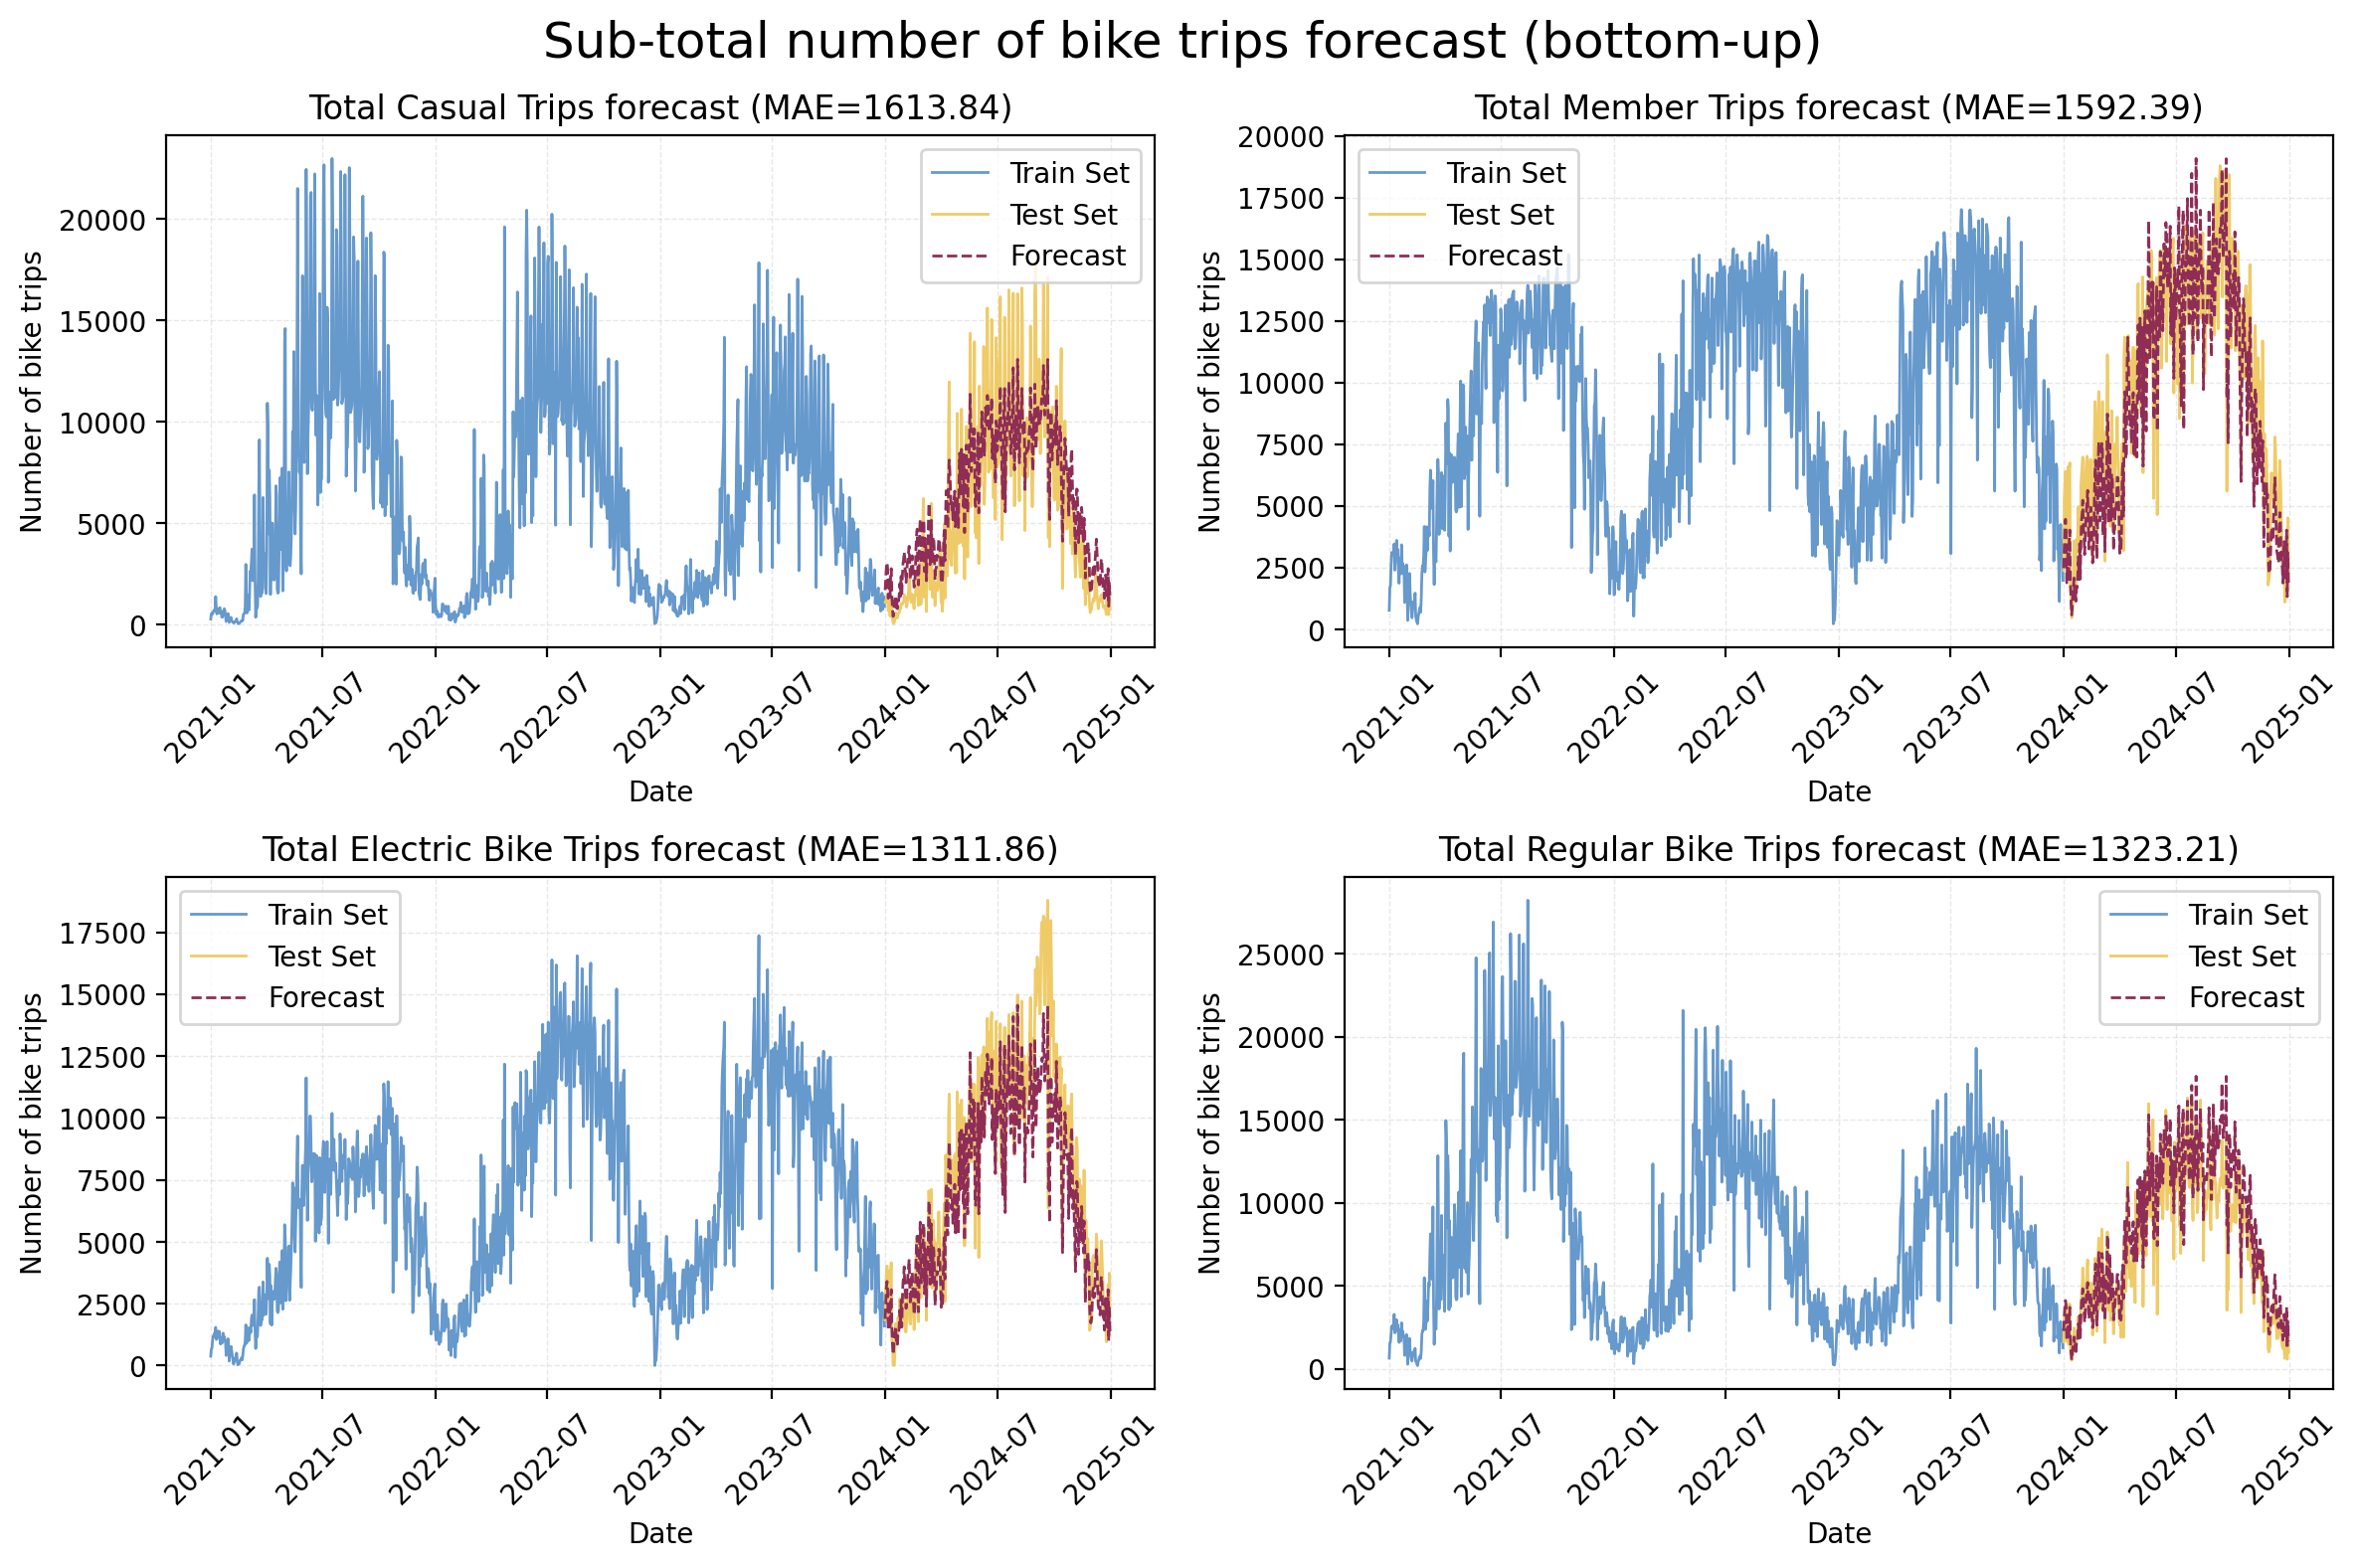

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

plot_trips(train=train["casual_total"], 
                    test=test["casual_total"],
                    forecast=td_bu_casual_total_forecast,
                    title=f"Total Casual Trips forecast (MAE={td_bu_casual_total_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_total"], 
                    test=test["member_total"],
                    forecast=td_bu_member_total_forecast,
                    title=f"Total Member Trips forecast (MAE={td_bu_member_total_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["electric_total"], 
                    test=test["electric_total"],
                    forecast=td_bu_electric_total_forecast,
                    title=f"Total Electric Bike Trips forecast (MAE={td_bu_electric_total_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["regular_total"], 
                    test=test["regular_total"],
                    forecast=td_bu_regular_total_forecast,
                    title=f"Total Regular Bike Trips forecast (MAE={td_bu_regular_total_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("Sub-total number of bike trips forecast (bottom-up)", fontsize=18)
plt.tight_layout()
plt.show()

In [26]:
ensemble_mae_scores['top-down']['mae']['casual_total'] = td_bu_casual_total_mae
ensemble_mae_scores['top-down']['mae']['member_total'] = td_bu_member_total_mae
ensemble_mae_scores['top-down']['mae']['electric_total'] = td_bu_electric_total_mae
ensemble_mae_scores['top-down']['mae']['regular_total'] = td_bu_regular_total_mae

---
#### Bottom-Up

![Bottom-Up Approach](./00_images/bottom_up.png)

In [27]:
# casual/regular
cr_ensemble_models, \
cr_ensemble_mae, \
cr_ensemble_forecast, \
cr_ensemble_weights = find_better_ensemble(test, "casual_regular_bike", forecasts, maes, True)


Models: ['xgboost']
weights: [1.]
MAE: 408.0877094998386

Models: ['rnn']
weights: [1.]
MAE: 494.41563017903815

Models: ['harimax']
weights: [1.]
MAE: 406.5966918060958

Models: ['xgboost', 'rnn']
weights: [0.59478659 0.40521341]
MAE: 375.55250480657185

Models: ['xgboost', 'harimax']
weights: [0.49816983 0.50183017]
MAE: 369.32327266859306

Models: ['rnn', 'harimax']
weights: [0.40345024 0.59654976]
MAE: 387.56128752661573

Models: ['xgboost', 'rnn', 'harimax']
weights: [0.37193762 0.25339192 0.37467046]
MAE: 359.30543054695903


                    Models      MAE
0  (xgboost, rnn, harimax) 359.3054
1       (xgboost, harimax) 369.3233
2           (xgboost, rnn) 375.5525
3           (rnn, harimax) 387.5613
4               (harimax,) 406.5967
5               (xgboost,) 408.0877
6                   (rnn,) 494.4156


The best ensemble ('xgboost', 'rnn', 'harimax') with MAE = 359.30543054695903



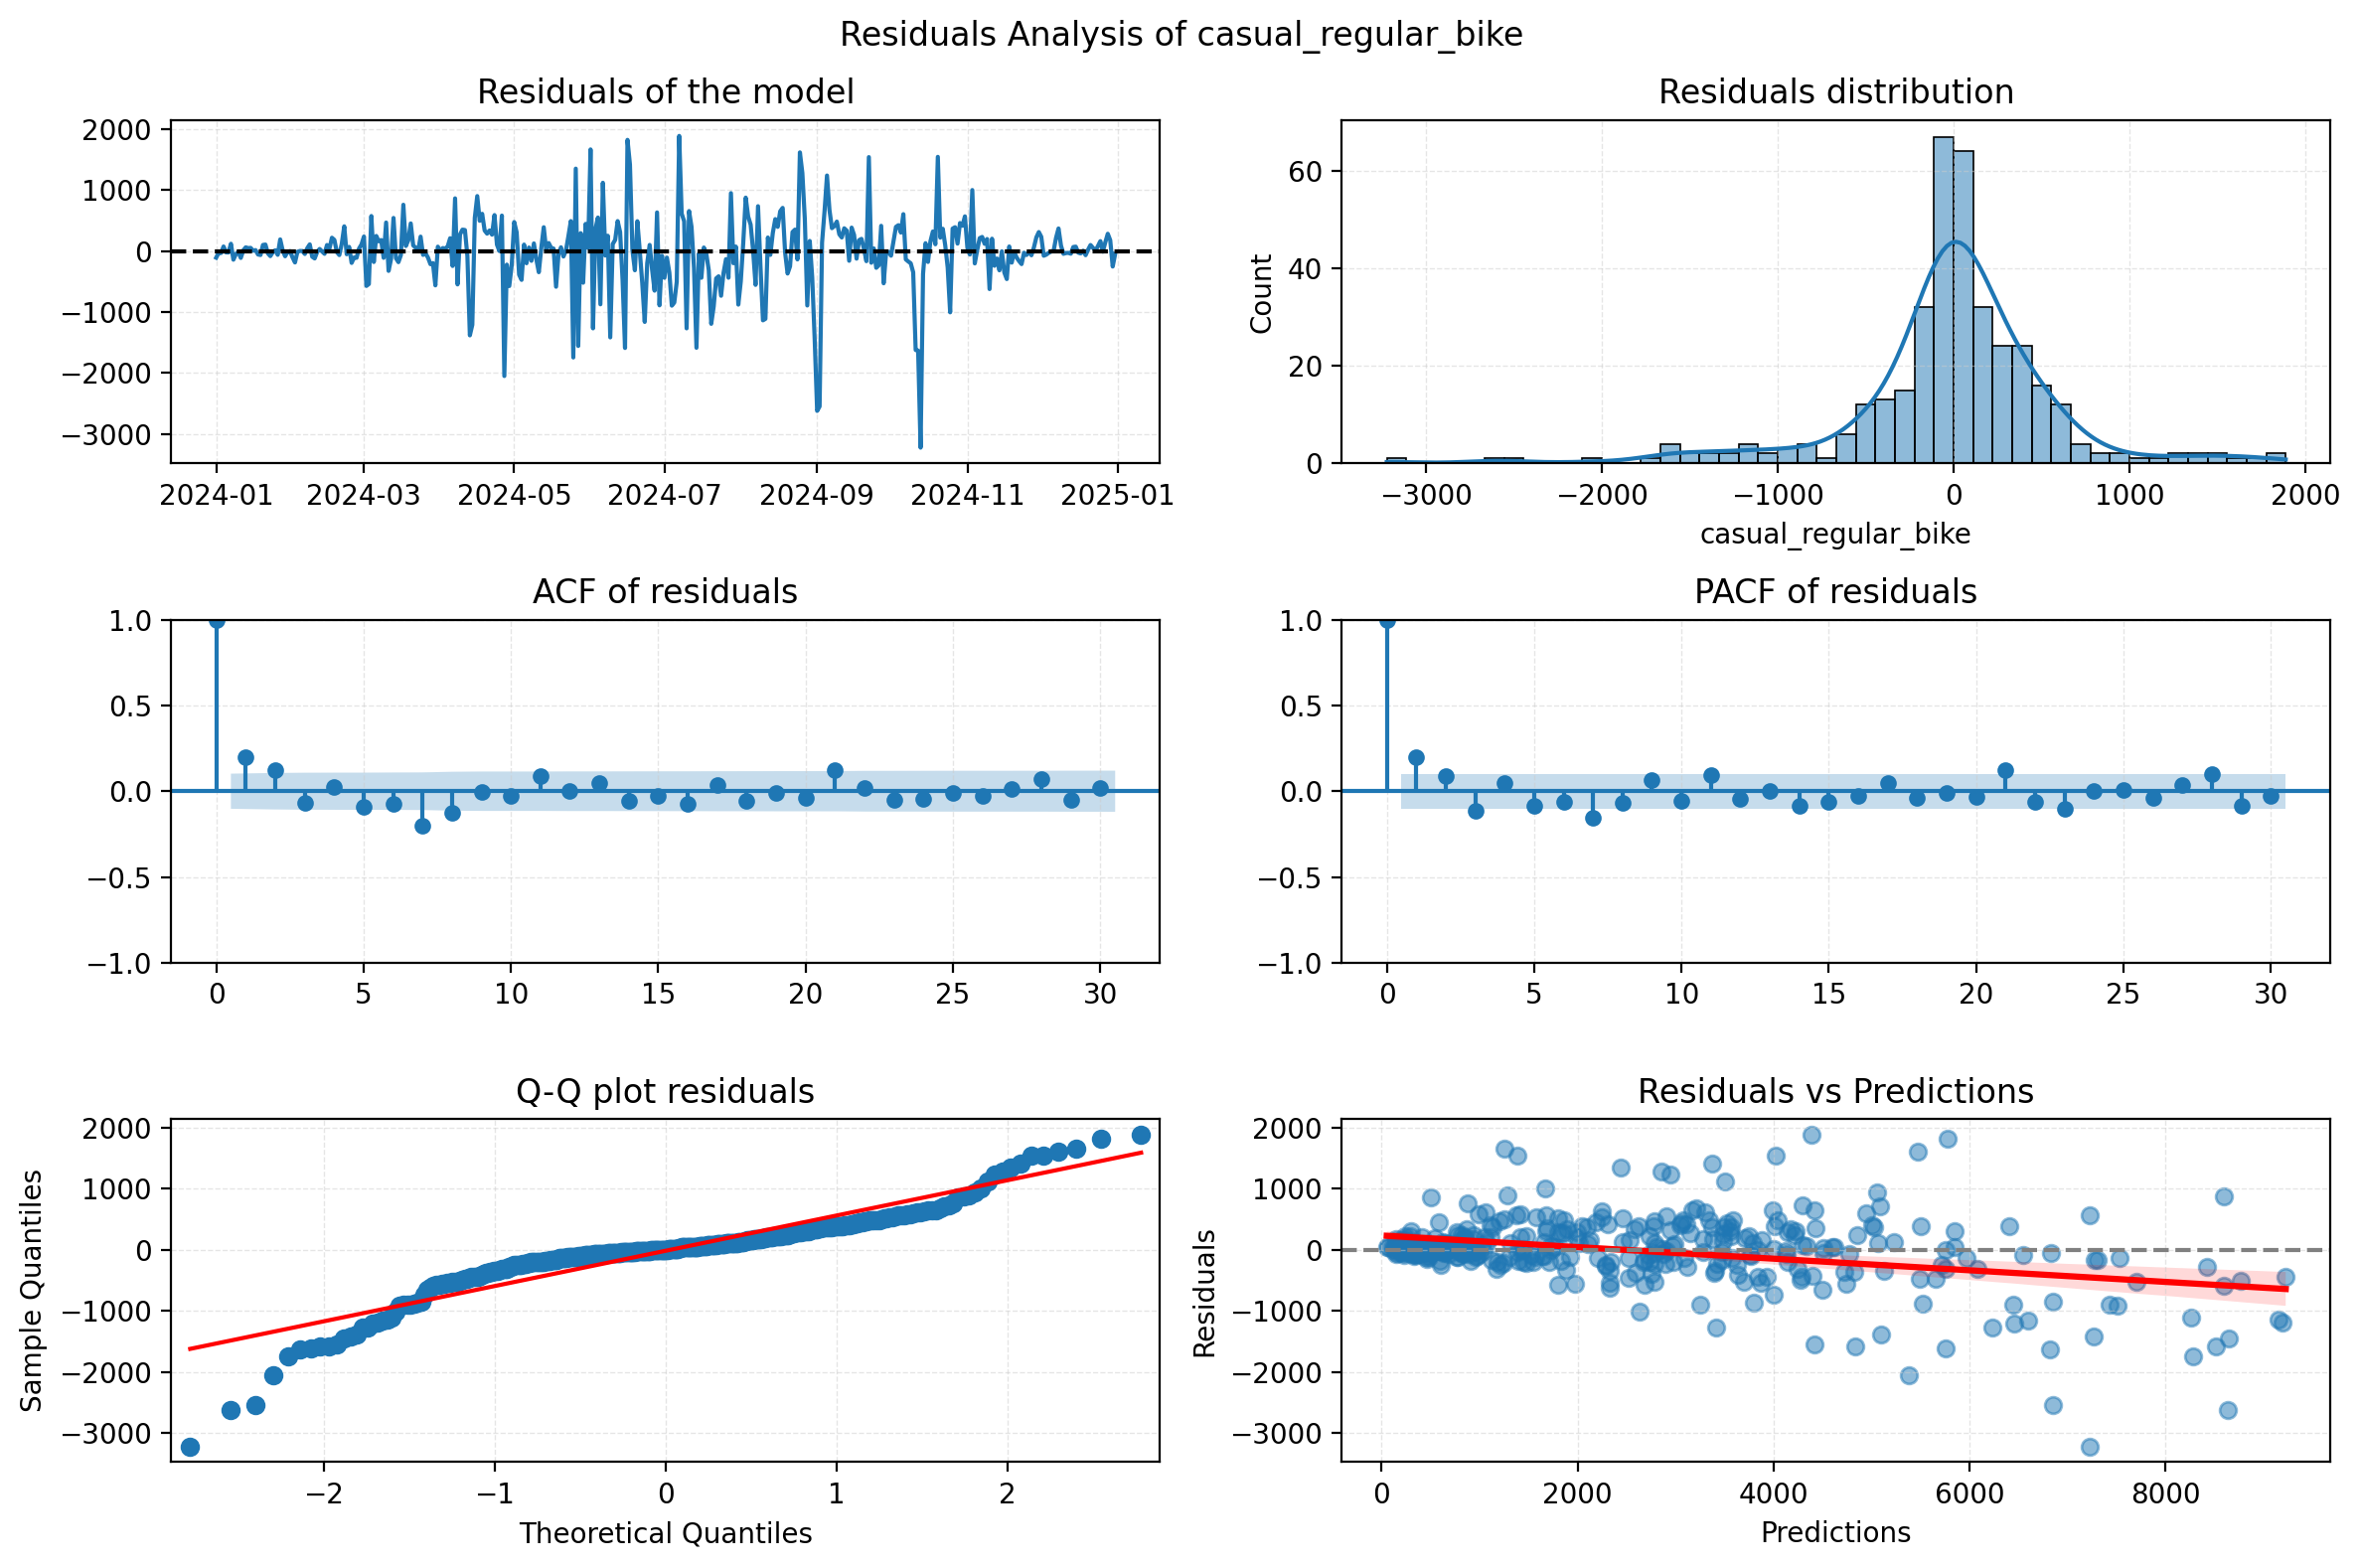


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  48.3413     0.0000
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -8.950022072978683
p-value: 8.77492258810353e-15
Time series is stationary

-- KPSS test --
ADF Statistic: 0.041366895588700034
p-value: 0.1
Time series is stationary


In [28]:
check_residuals(cr_ensemble_forecast, test["casual_regular_bike"], "casual_regular_bike")

In [29]:
# member/regular
mr_ensemble_models, \
mr_ensemble_mae, \
mr_ensemble_forecast, \
mr_ensemble_weights = find_better_ensemble(test, "member_regular_bike", forecasts, maes, True)


Models: ['xgboost']
weights: [1.]
MAE: 454.8270567180029

Models: ['rnn']
weights: [1.]
MAE: 458.1067596512738

Models: ['harimax']
weights: [1.]
MAE: 407.0504539331795

Models: ['xgboost', 'rnn']
weights: [0.50359244 0.49640756]
MAE: 421.20188463985687

Models: ['xgboost', 'harimax']
weights: [0.44473664 0.55526336]
MAE: 383.8185722863139

Models: ['rnn', 'harimax']
weights: [0.44119091 0.55880909]
MAE: 391.46819974095104

Models: ['xgboost', 'rnn', 'harimax']
weights: [0.30919027 0.30477897 0.38603076]
MAE: 383.35032889853323


                    Models      MAE
0  (xgboost, rnn, harimax) 383.3503
1       (xgboost, harimax) 383.8186
2           (rnn, harimax) 391.4682
3               (harimax,) 407.0505
4           (xgboost, rnn) 421.2019
5               (xgboost,) 454.8271
6                   (rnn,) 458.1068


The best ensemble ('xgboost', 'rnn', 'harimax') with MAE = 383.35032889853323



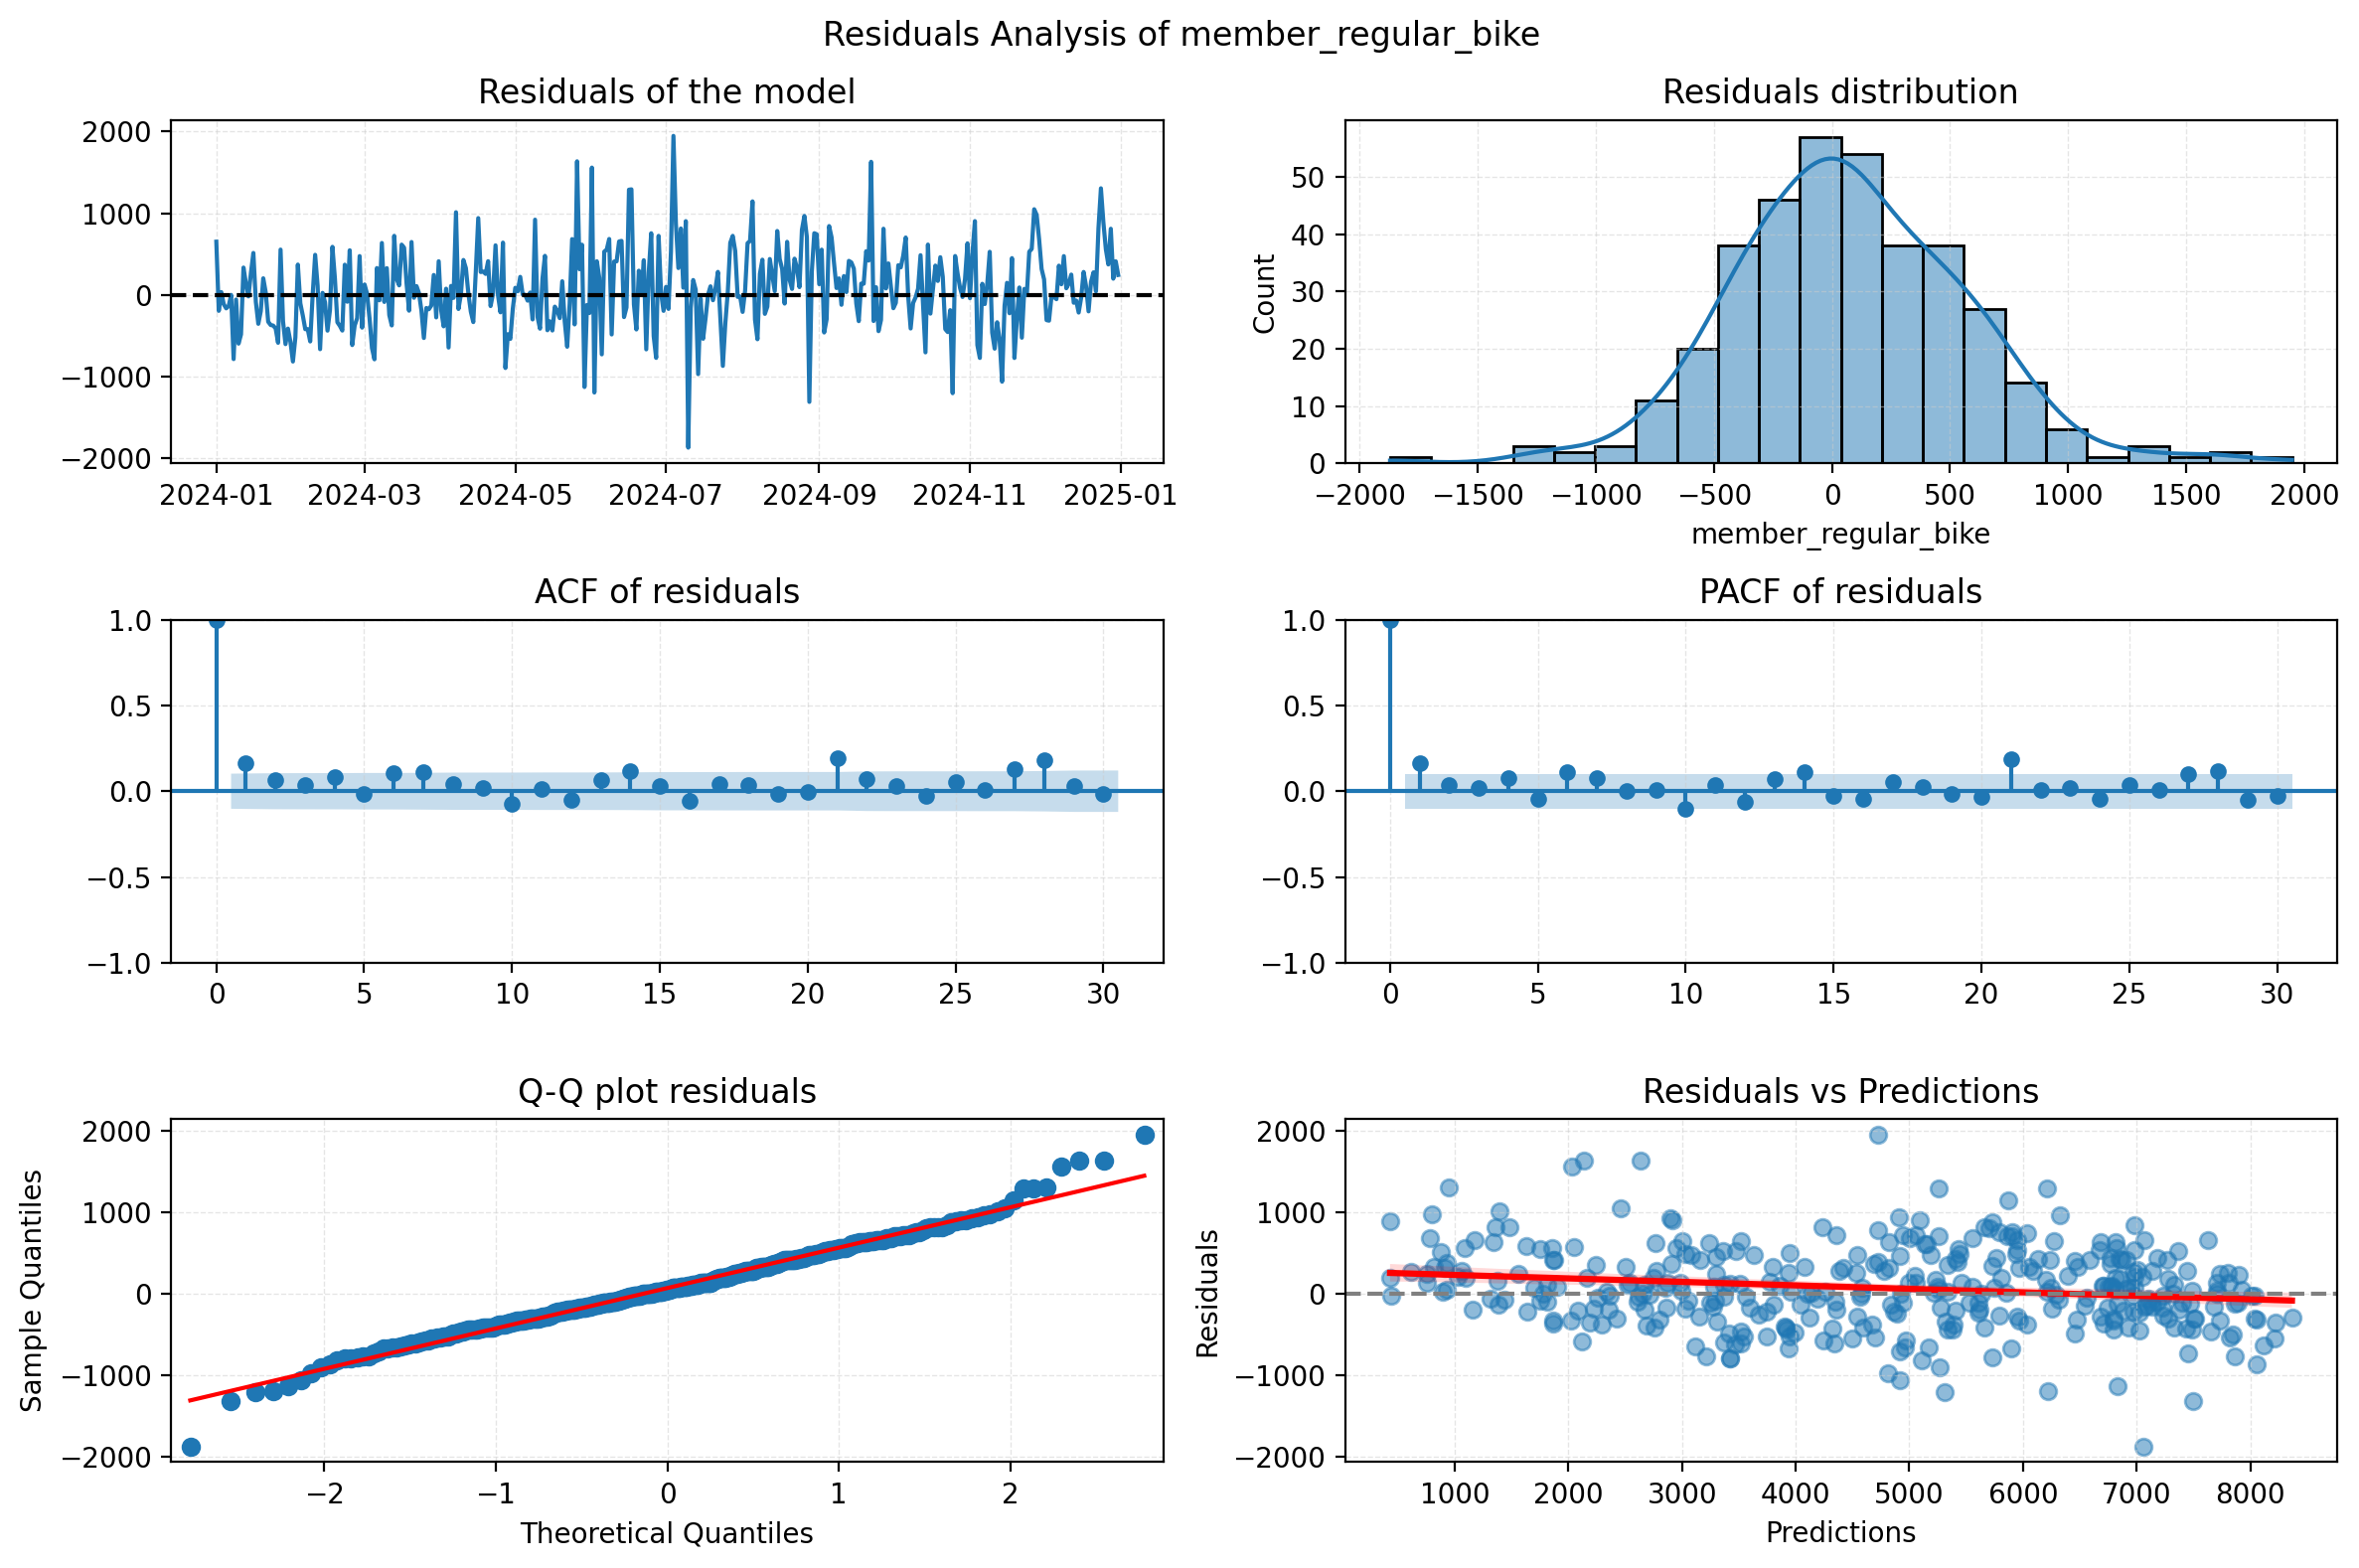


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  25.9753     0.0038
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -16.201836904647493
p-value: 4.0697420991696215e-29
Time series is stationary

-- KPSS test --
ADF Statistic: 0.1372581951535013
p-value: 0.06618852749351611
Time series is stationary


In [30]:
check_residuals(mr_ensemble_forecast, test["member_regular_bike"], "member_regular_bike")

In [31]:
# casual/electric
ce_ensemble_models, \
ce_ensemble_mae, \
ce_ensemble_forecast, \
ce_ensemble_weights = find_better_ensemble(test, "casual_electric_bike", forecasts, maes, True)


Models: ['xgboost']
weights: [1.]
MAE: 427.7170776721558

Models: ['rnn']
weights: [1.]
MAE: 498.82420138877313

Models: ['harimax']
weights: [1.]
MAE: 388.3747675109646

Models: ['xgboost', 'rnn']
weights: [0.57629533 0.42370467]
MAE: 424.443511843428

Models: ['xgboost', 'harimax']
weights: [0.45190359 0.54809641]
MAE: 376.30171317457024

Models: ['rnn', 'harimax']
weights: [0.37740768 0.62259232]
MAE: 393.02378400065

Models: ['xgboost', 'rnn', 'harimax']
weights: [0.3392035  0.24938968 0.41140682]
MAE: 385.4298480735434


                    Models      MAE
0       (xgboost, harimax) 376.3017
1  (xgboost, rnn, harimax) 385.4298
2               (harimax,) 388.3748
3           (rnn, harimax) 393.0238
4           (xgboost, rnn) 424.4435
5               (xgboost,) 427.7171
6                   (rnn,) 498.8242


The best ensemble ('xgboost', 'harimax') with MAE = 376.30171317457024



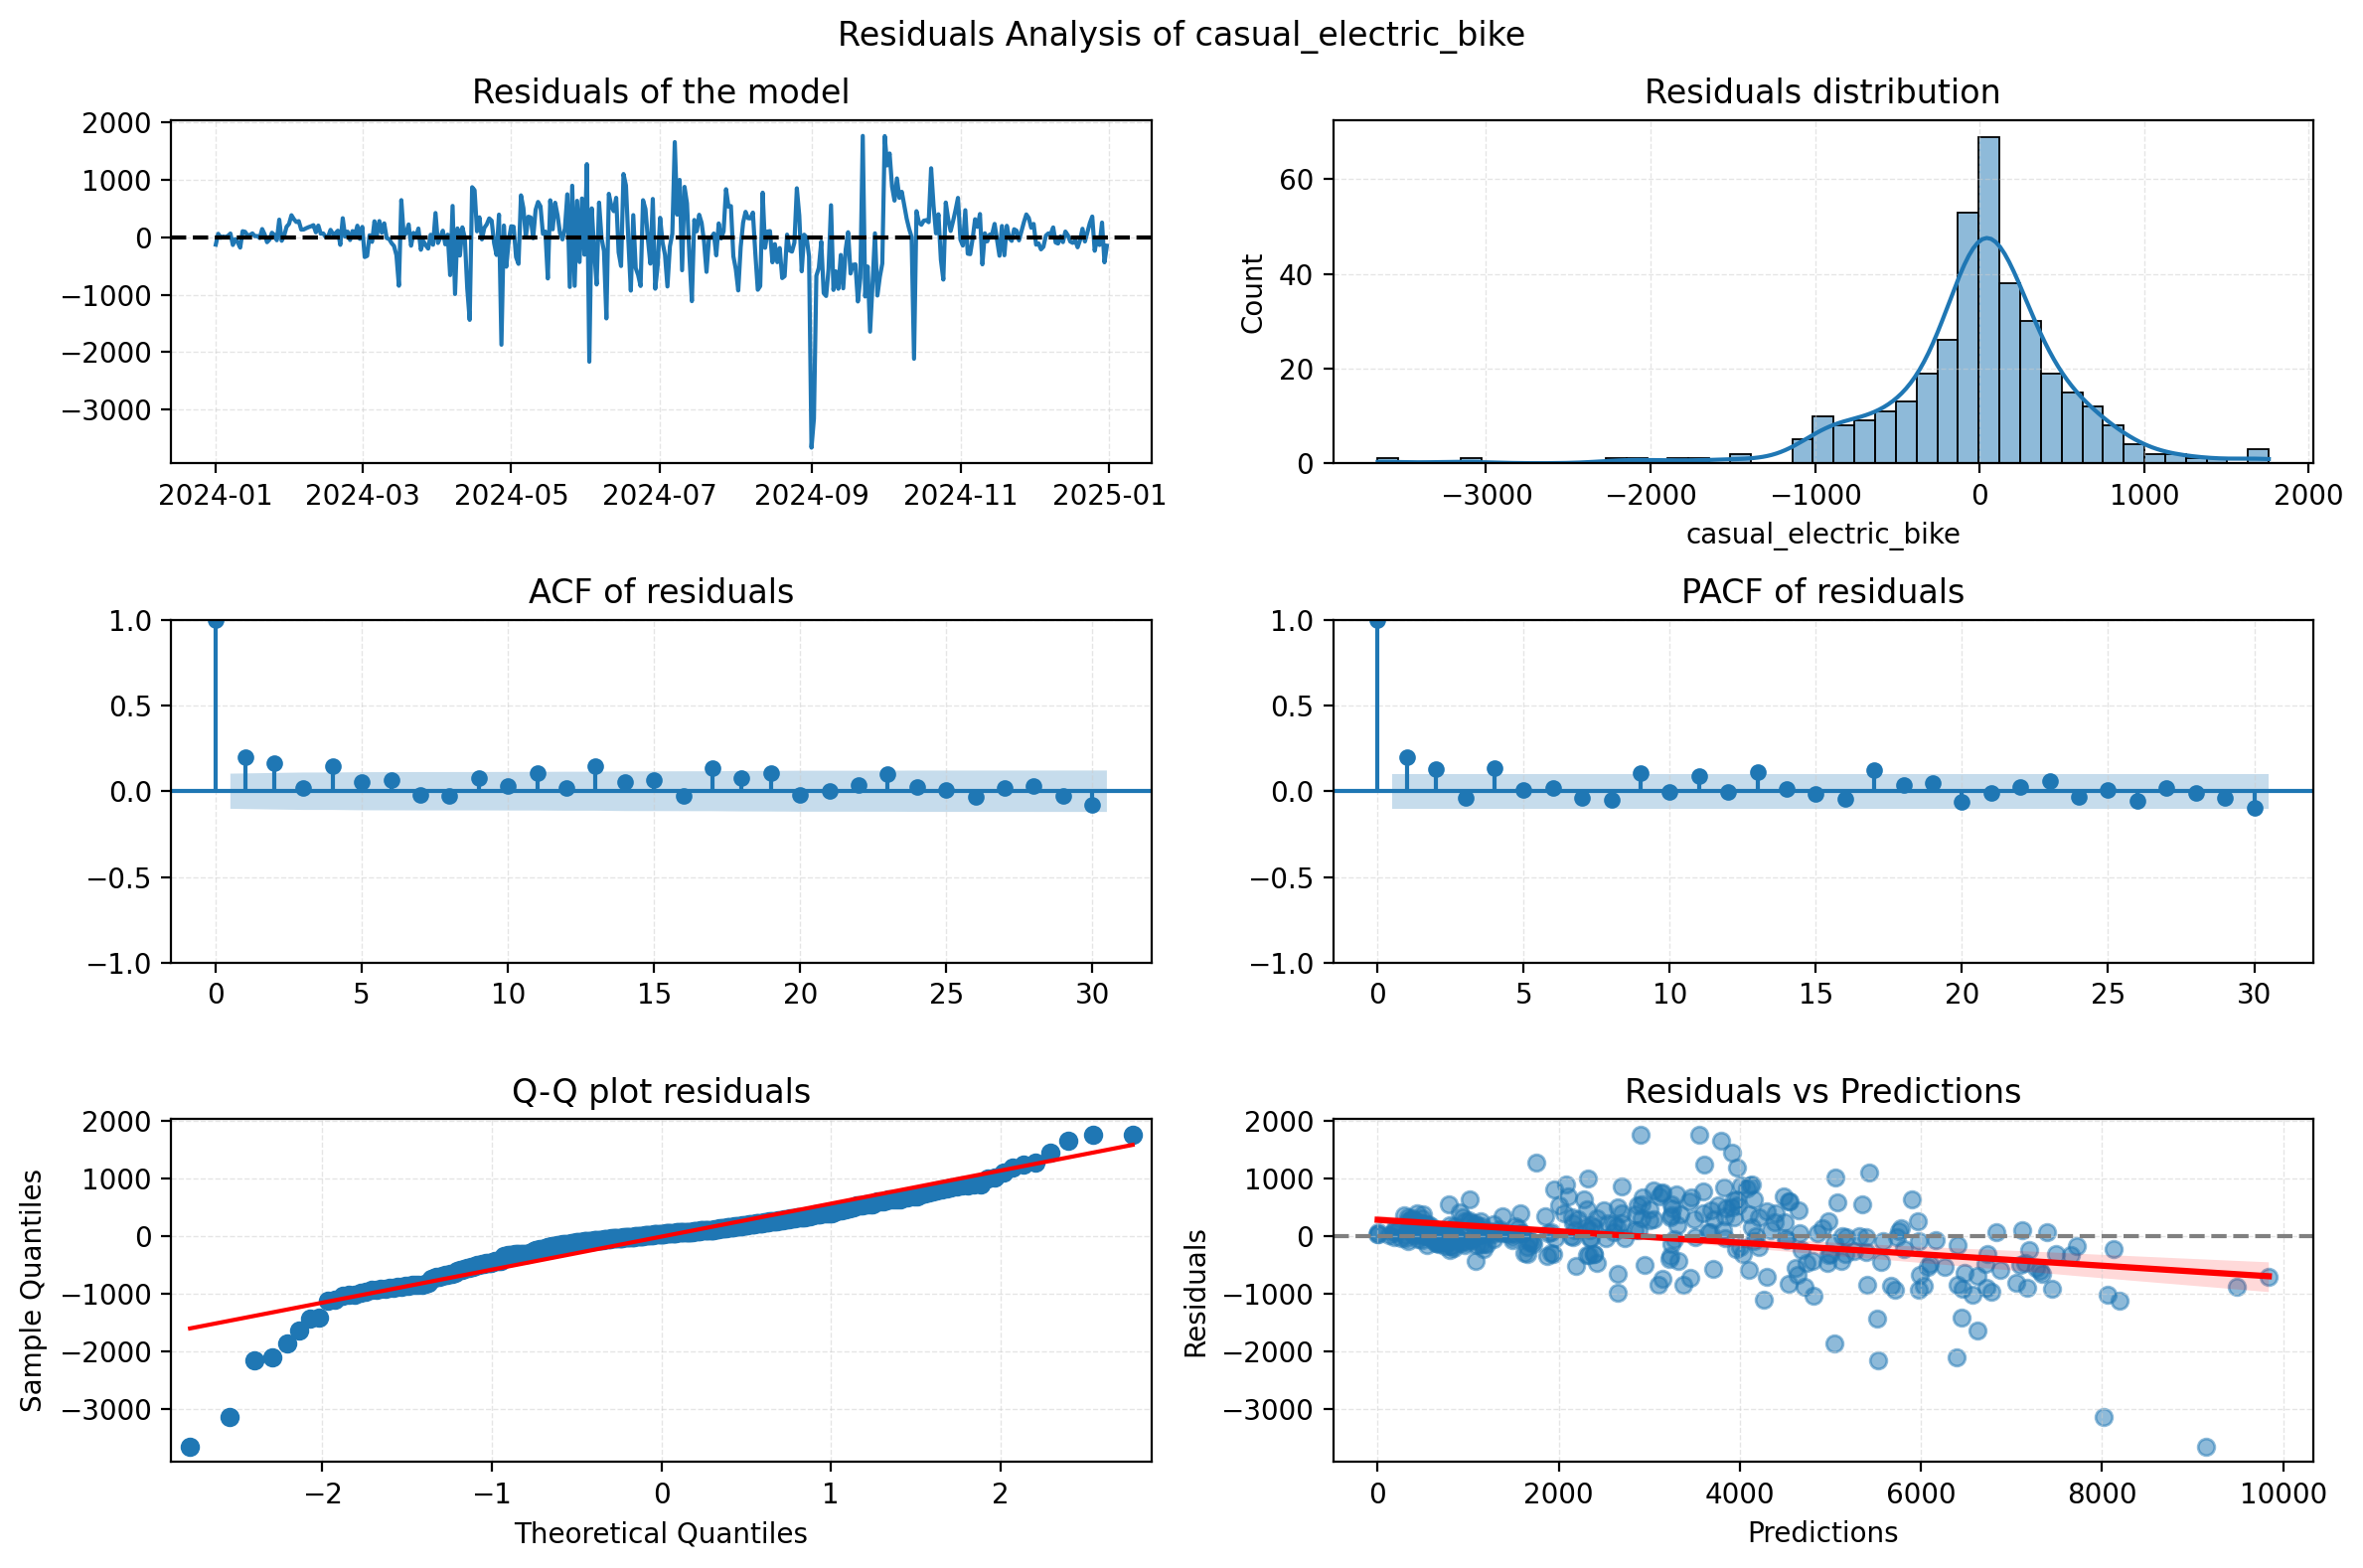


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  38.6525     0.0000
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -7.423898527071232
p-value: 6.625863211126856e-11
Time series is stationary

-- KPSS test --
ADF Statistic: 0.1094870356241071
p-value: 0.1
Time series is stationary


In [32]:
check_residuals(ce_ensemble_forecast, test["casual_electric_bike"], "casual_electric_bike")

In [33]:
# member/electric
me_ensemble_models, \
me_ensemble_mae, \
me_ensemble_forecast, \
me_ensemble_weights = find_better_ensemble(test, "member_electric_bike", forecasts, maes, True)


Models: ['xgboost']
weights: [1.]
MAE: 562.4547472677596

Models: ['rnn']
weights: [1.]
MAE: 520.0867845878983

Models: ['harimax']
weights: [1.]
MAE: 423.82787499164164

Models: ['xgboost', 'rnn']
weights: [0.46092236 0.53907764]
MAE: 507.69622671337595

Models: ['xgboost', 'harimax']
weights: [0.36216805 0.63783195]
MAE: 432.1275425073428

Models: ['rnn', 'harimax']
weights: [0.39907122 0.60092878]
MAE: 420.3737498206608

Models: ['xgboost', 'rnn', 'harimax']
weights: [0.25440684 0.29754477 0.44804839]
MAE: 434.78716770347376


                    Models      MAE
0           (rnn, harimax) 420.3737
1               (harimax,) 423.8279
2       (xgboost, harimax) 432.1275
3  (xgboost, rnn, harimax) 434.7872
4           (xgboost, rnn) 507.6962
5                   (rnn,) 520.0868
6               (xgboost,) 562.4547


The best ensemble ('rnn', 'harimax') with MAE = 420.3737498206608



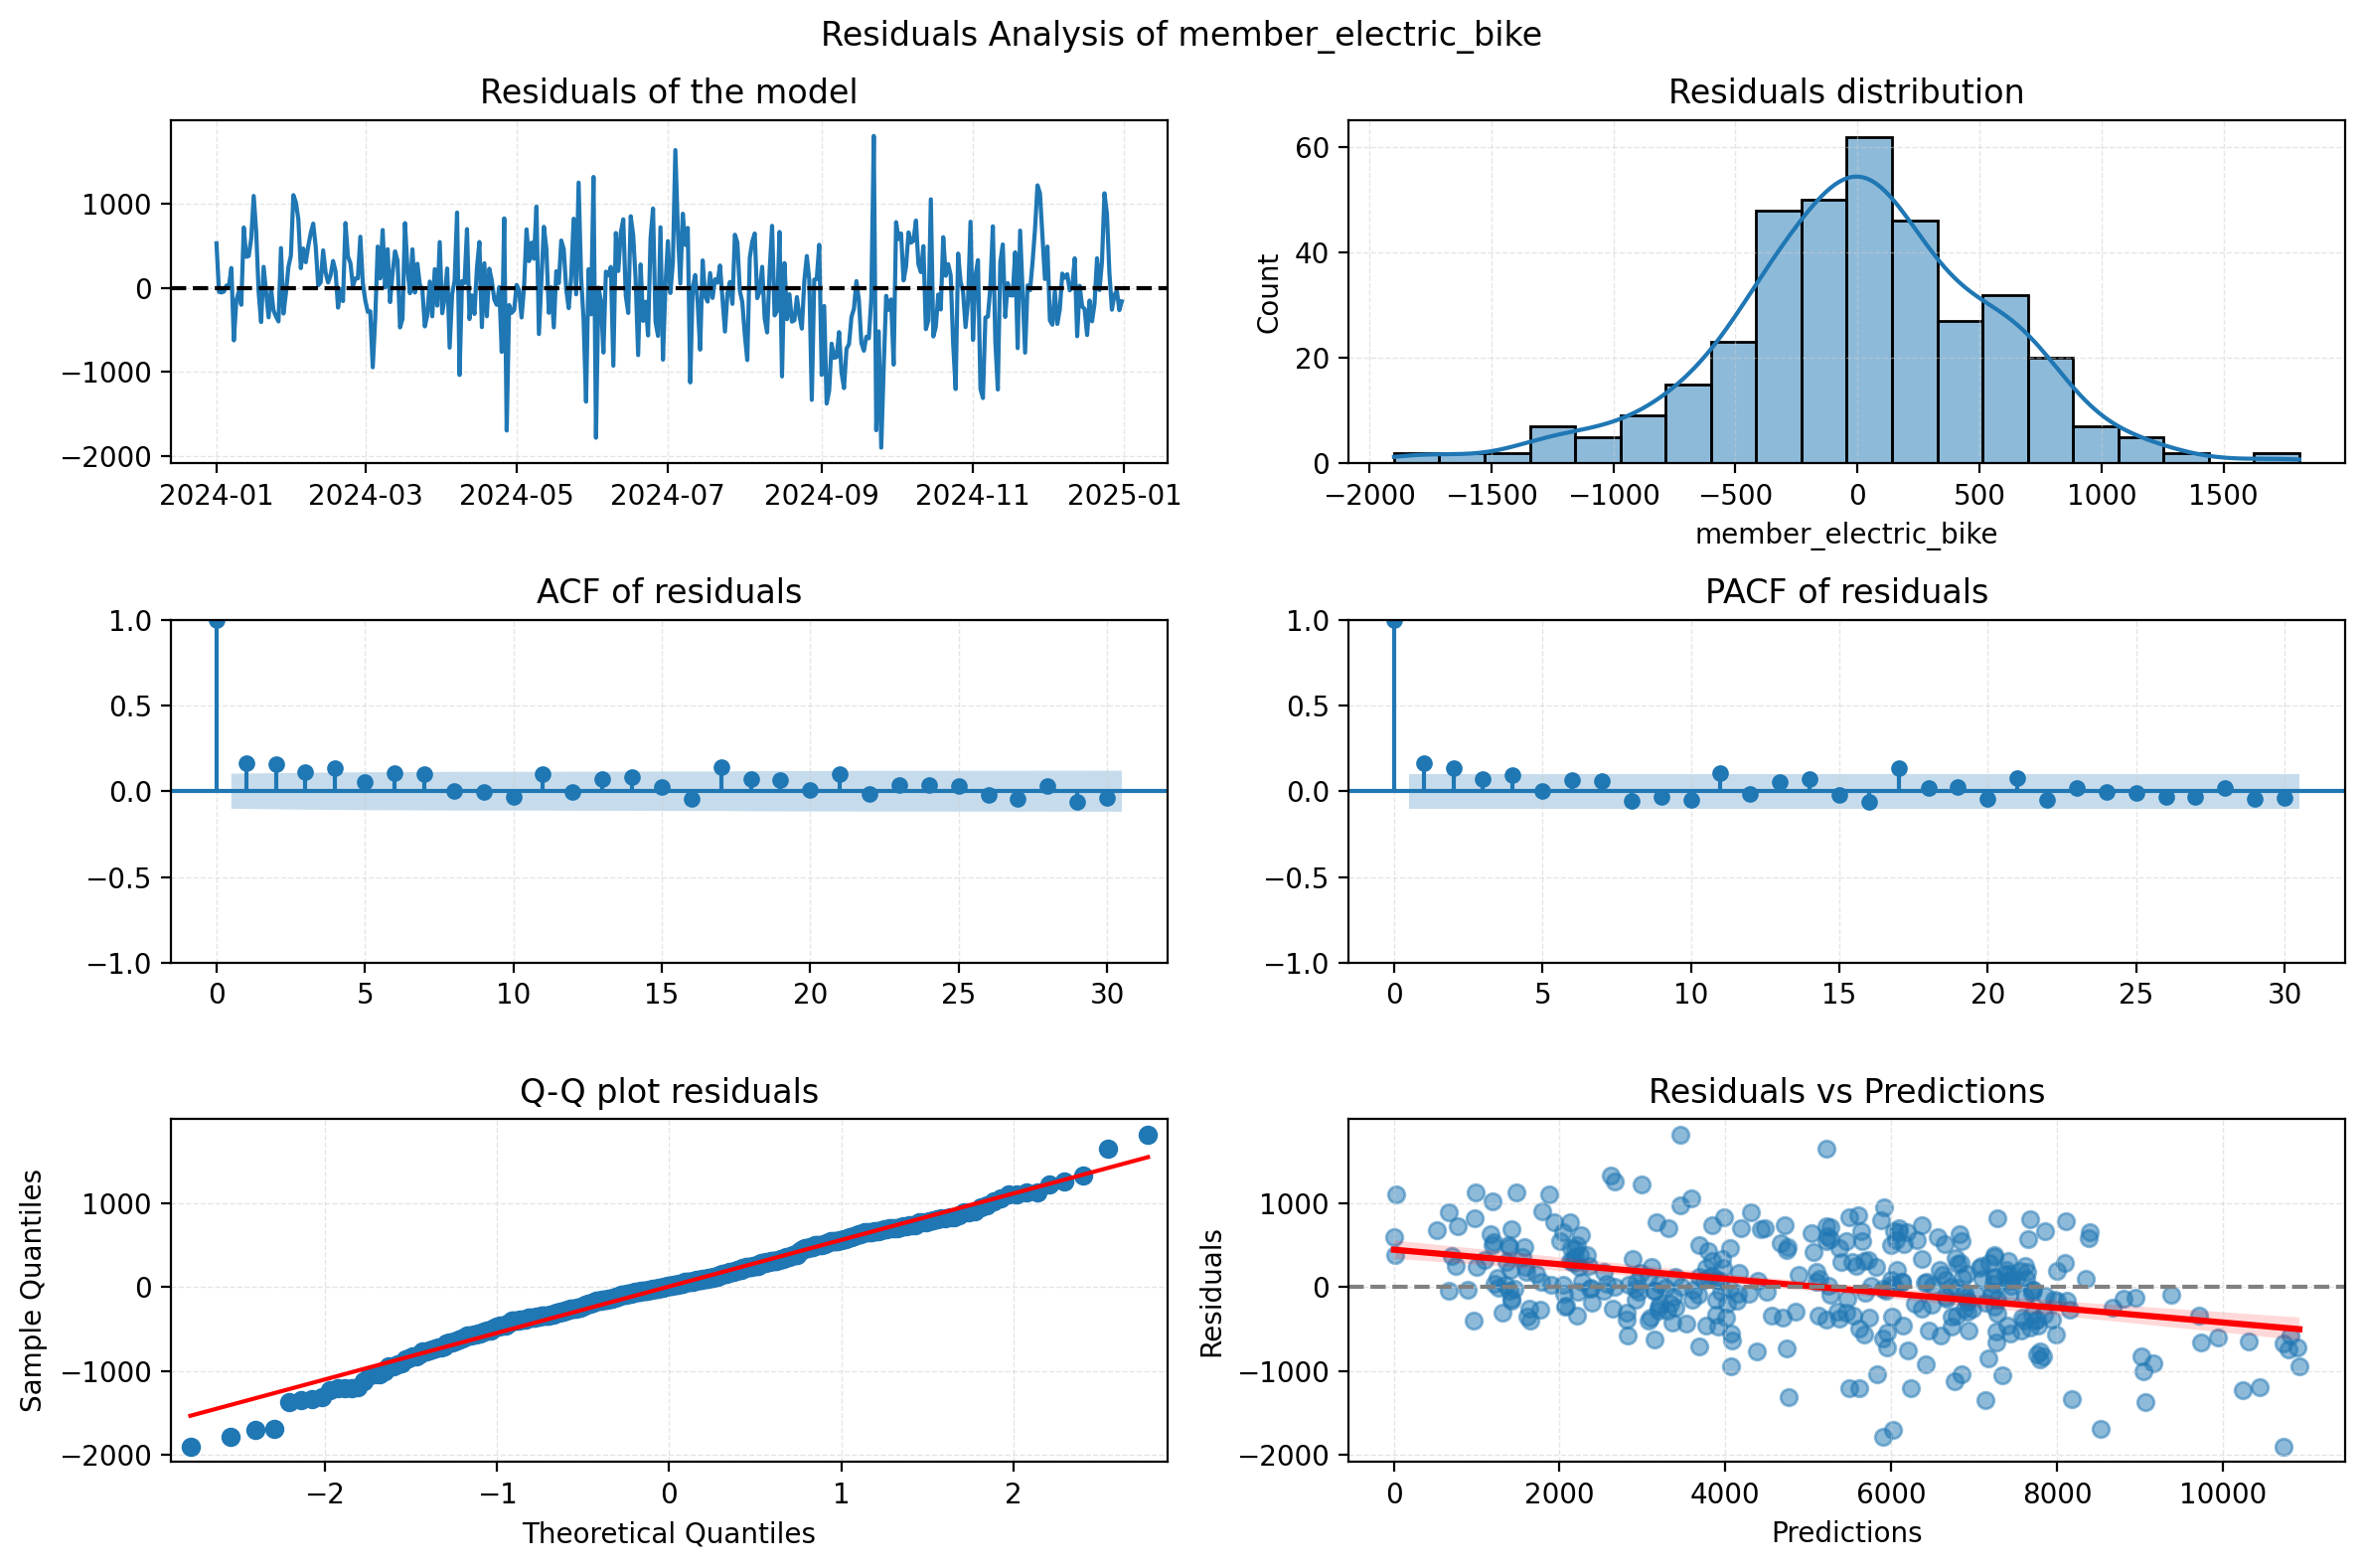


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  40.3353     0.0000
Residuals are autocorrelated

-- Dickey–Fuller test --
ADF Statistic: -7.1516777263708455
p-value: 3.129372465794953e-10
Time series is stationary

-- KPSS test --
ADF Statistic: 0.10999758130483275
p-value: 0.1
Time series is stationary


In [34]:
check_residuals(me_ensemble_forecast, test["member_electric_bike"], "member_electric_bike")

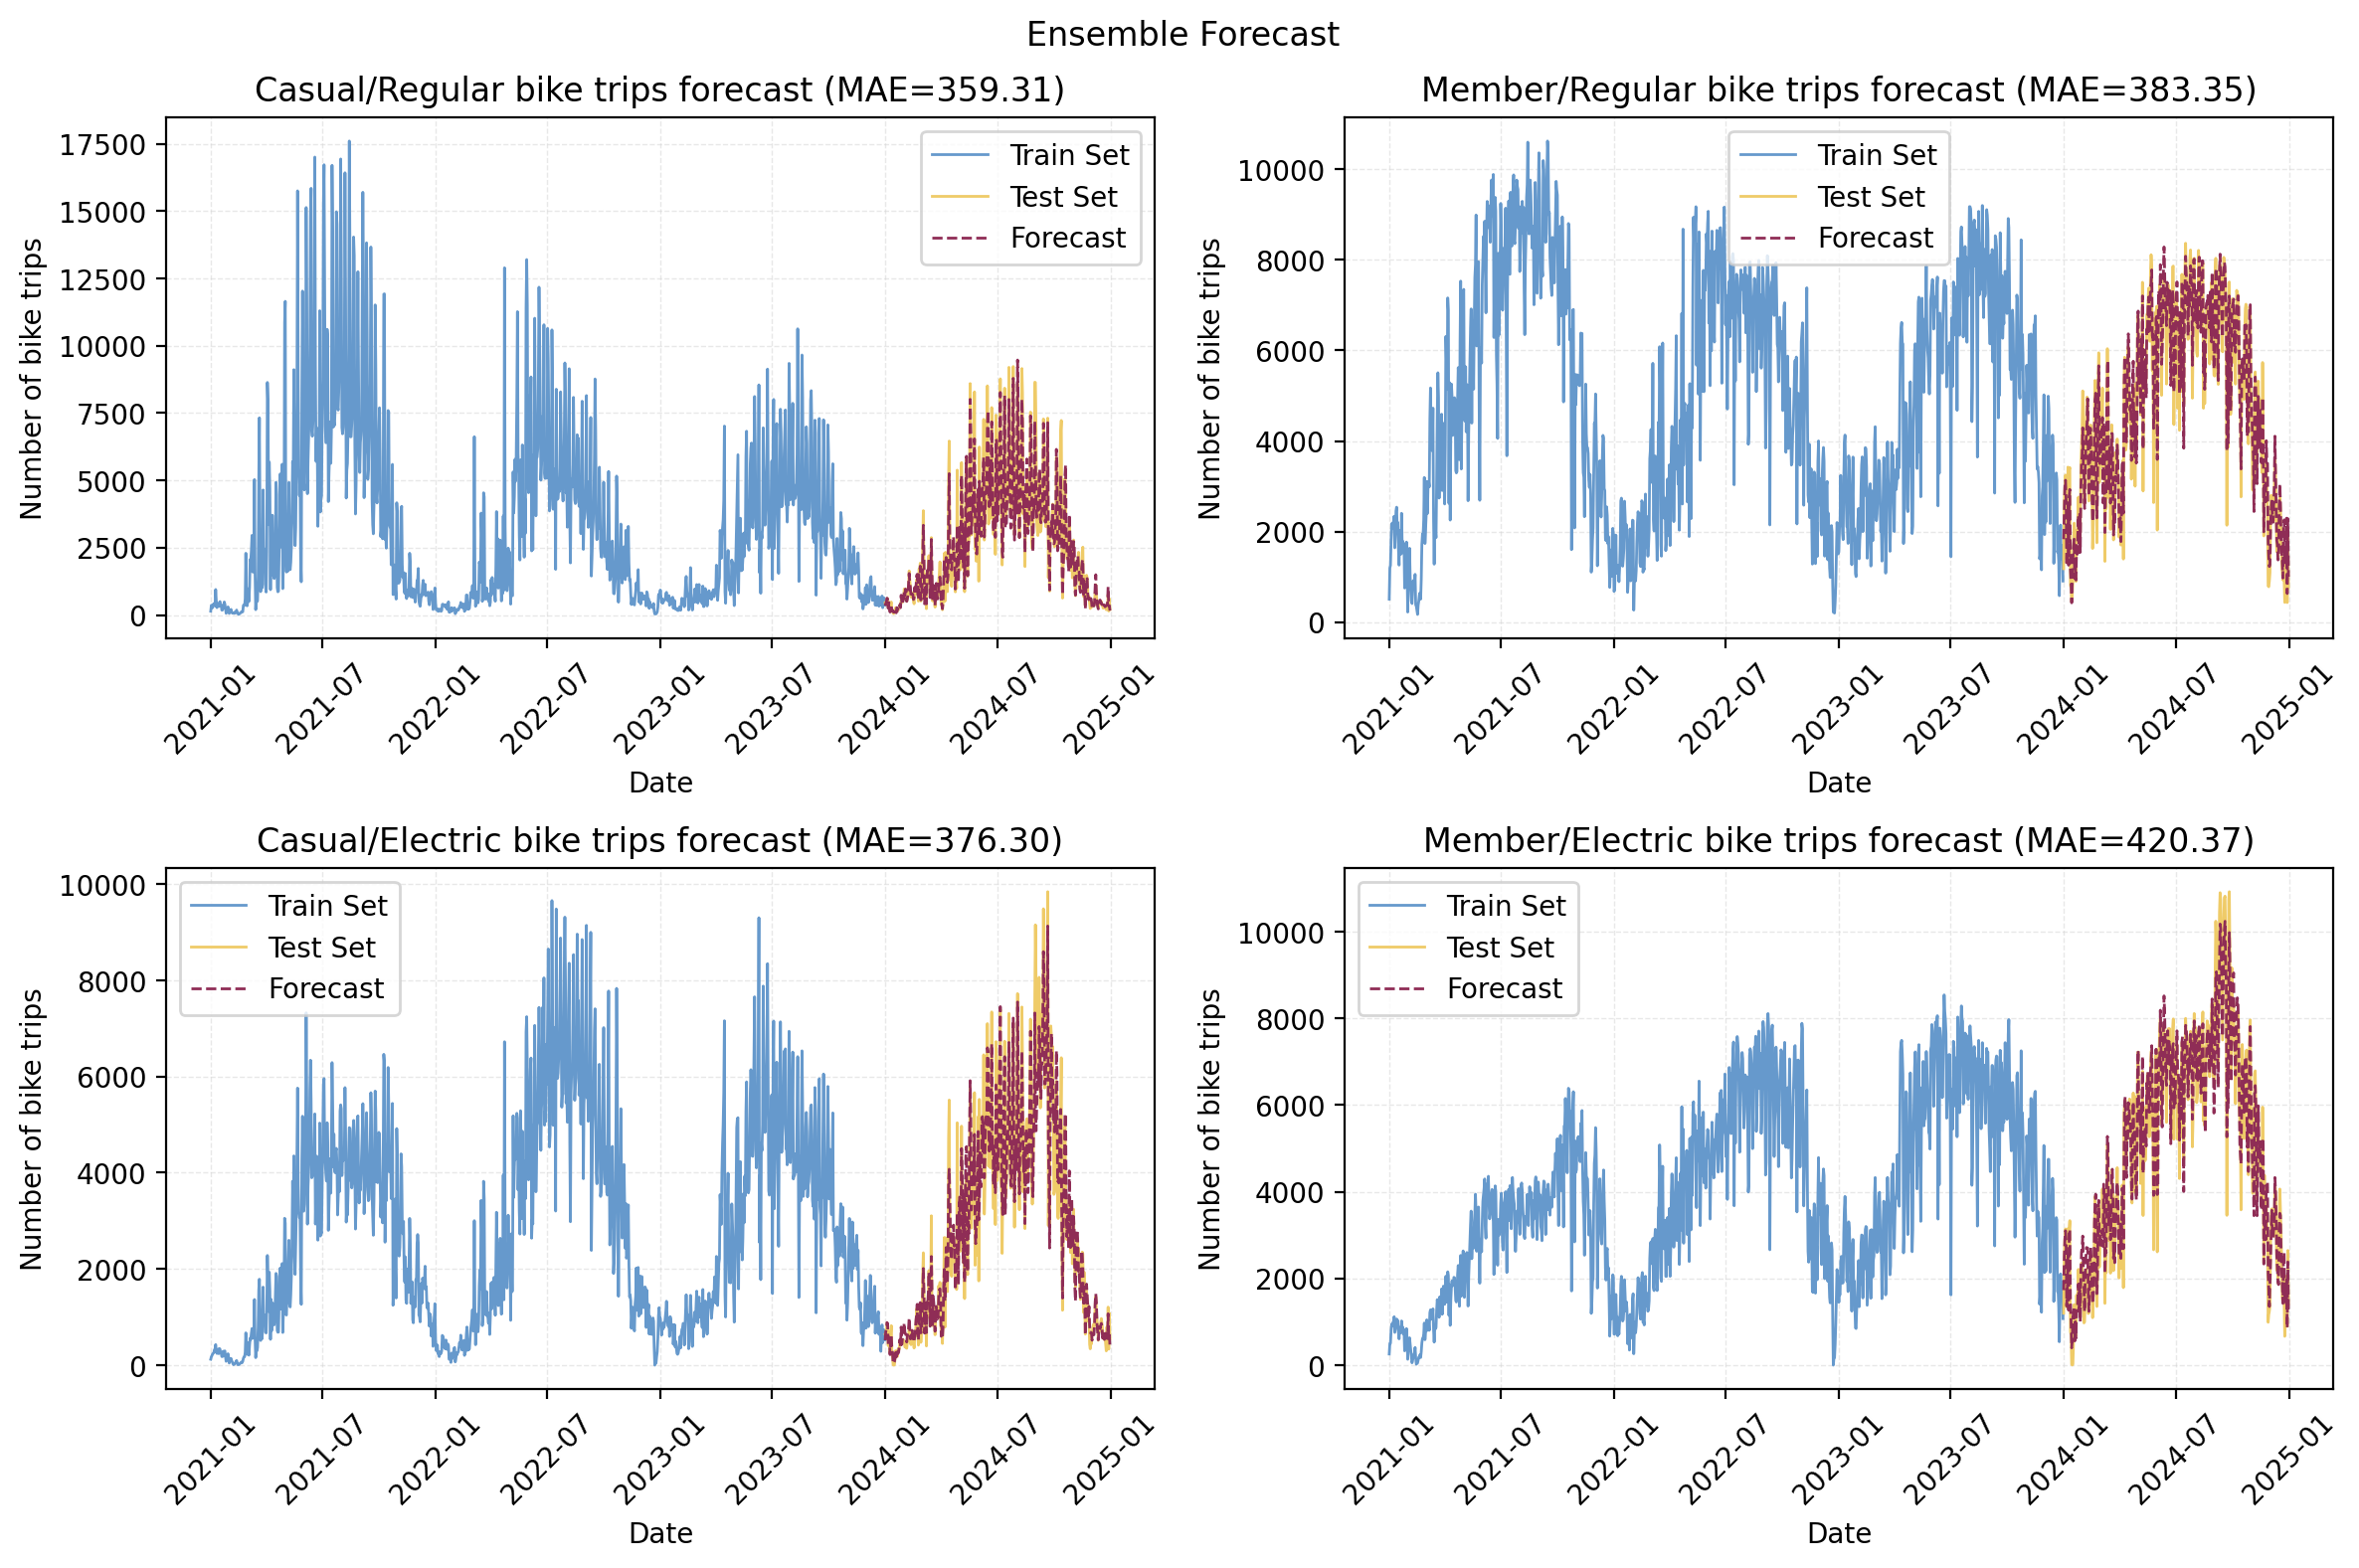

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

plot_trips(train=train["casual_regular_bike"], 
                    test=test["casual_regular_bike"],
                    forecast=pd.DataFrame(cr_ensemble_forecast, test.index),
                    title=f"Casual/Regular bike trips forecast (MAE={cr_ensemble_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_regular_bike"], 
                    test=test["member_regular_bike"],
                    forecast=pd.DataFrame(mr_ensemble_forecast, test.index),
                    title=f"Member/Regular bike trips forecast (MAE={mr_ensemble_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["casual_electric_bike"], 
                    test=test["casual_electric_bike"],
                    forecast=pd.DataFrame(ce_ensemble_forecast, test.index),
                    title=f"Casual/Electric bike trips forecast (MAE={ce_ensemble_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["member_electric_bike"], 
                    test=test["member_electric_bike"],
                    forecast=pd.DataFrame(me_ensemble_forecast, test.index),
                    title=f"Member/Electric bike trips forecast (MAE={me_ensemble_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("Ensemble Forecast")
plt.tight_layout()
plt.show()

In [36]:
ensemble_mae_scores['bottom-up']['mae']['casual_regular_bike'] = cr_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['member_regular_bike'] = mr_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['casual_electric_bike'] = ce_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['member_electric_bike'] = me_ensemble_mae

##### Total forecasting (Bottom-Up)

In [37]:
bu_total_ensemble_forecast = cr_ensemble_forecast + mr_ensemble_forecast + ce_ensemble_forecast + me_ensemble_forecast
bu_total_ensemble_mae = mean_absolute_error(test["total_rides"], bu_total_ensemble_forecast)

<Figure size 1200x400 with 0 Axes>

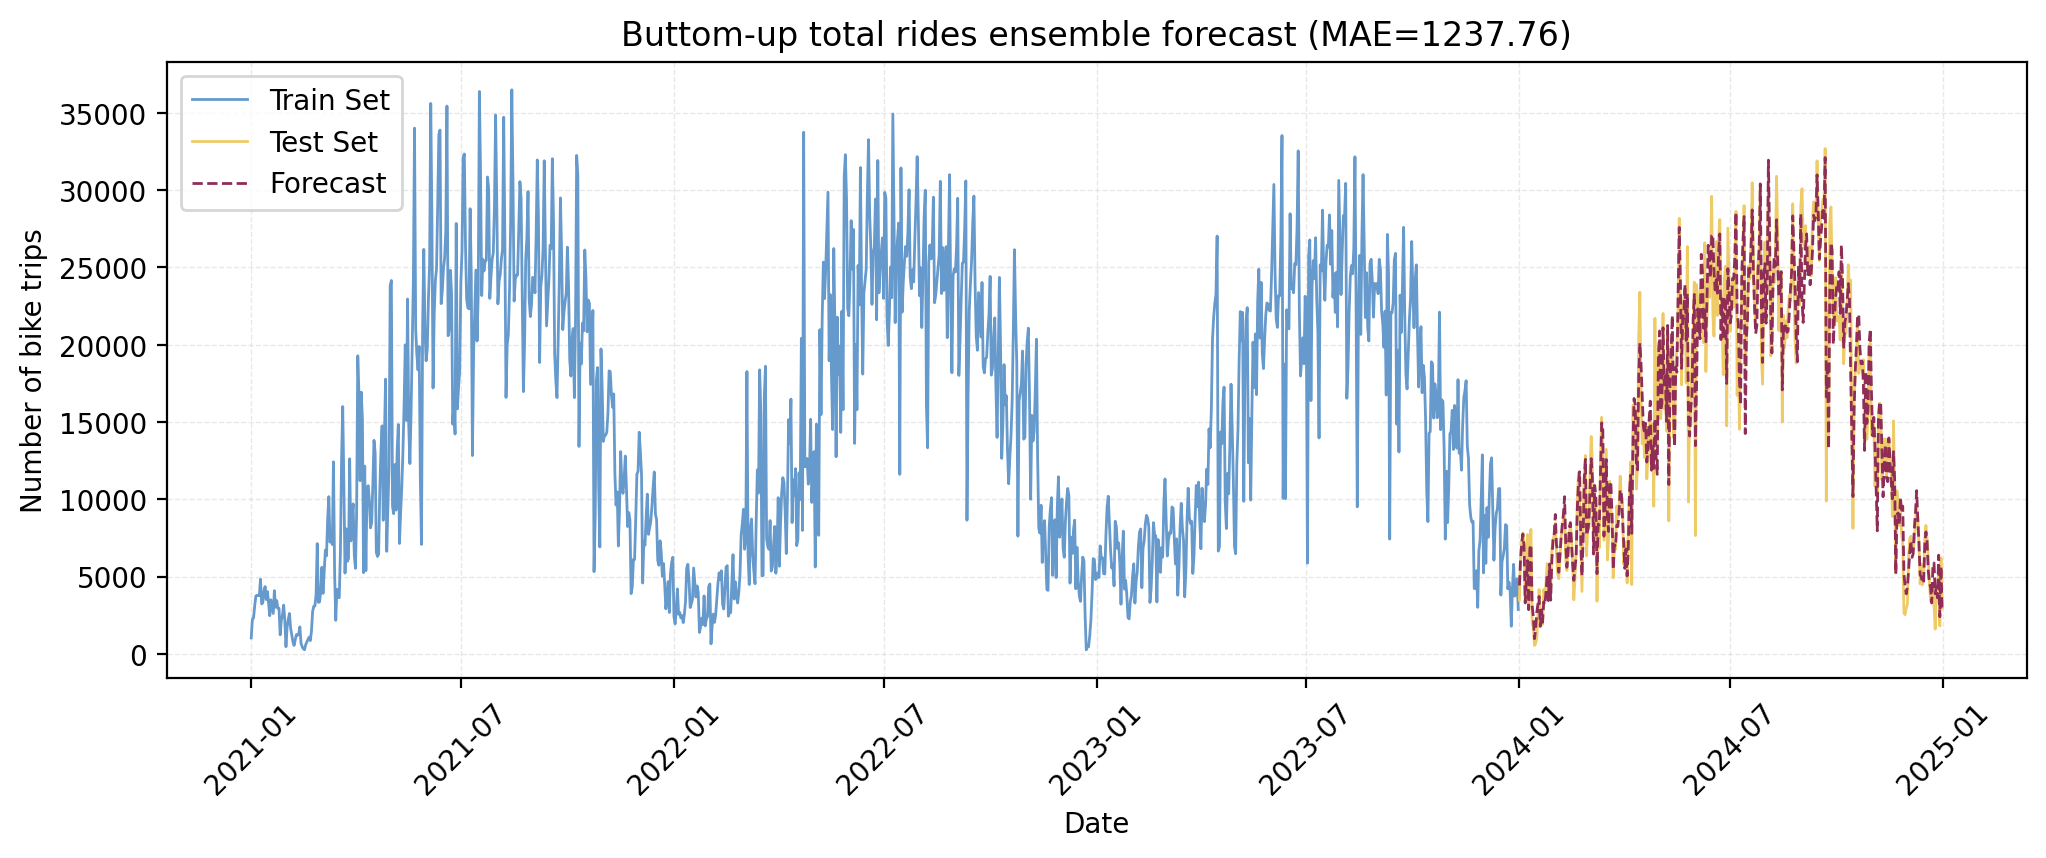

In [38]:
plt.figure(figsize=(12, 4))

_, ax = plt.subplots(1, 1, figsize=(12, 4))
plot_trips(ax, train["total_rides"], test["total_rides"], 
           forecast=pd.DataFrame(bu_total_ensemble_forecast, index=test.index),
           title=f"Buttom-up total rides ensemble forecast (MAE={bu_total_ensemble_mae:.2f})")

plt.show()

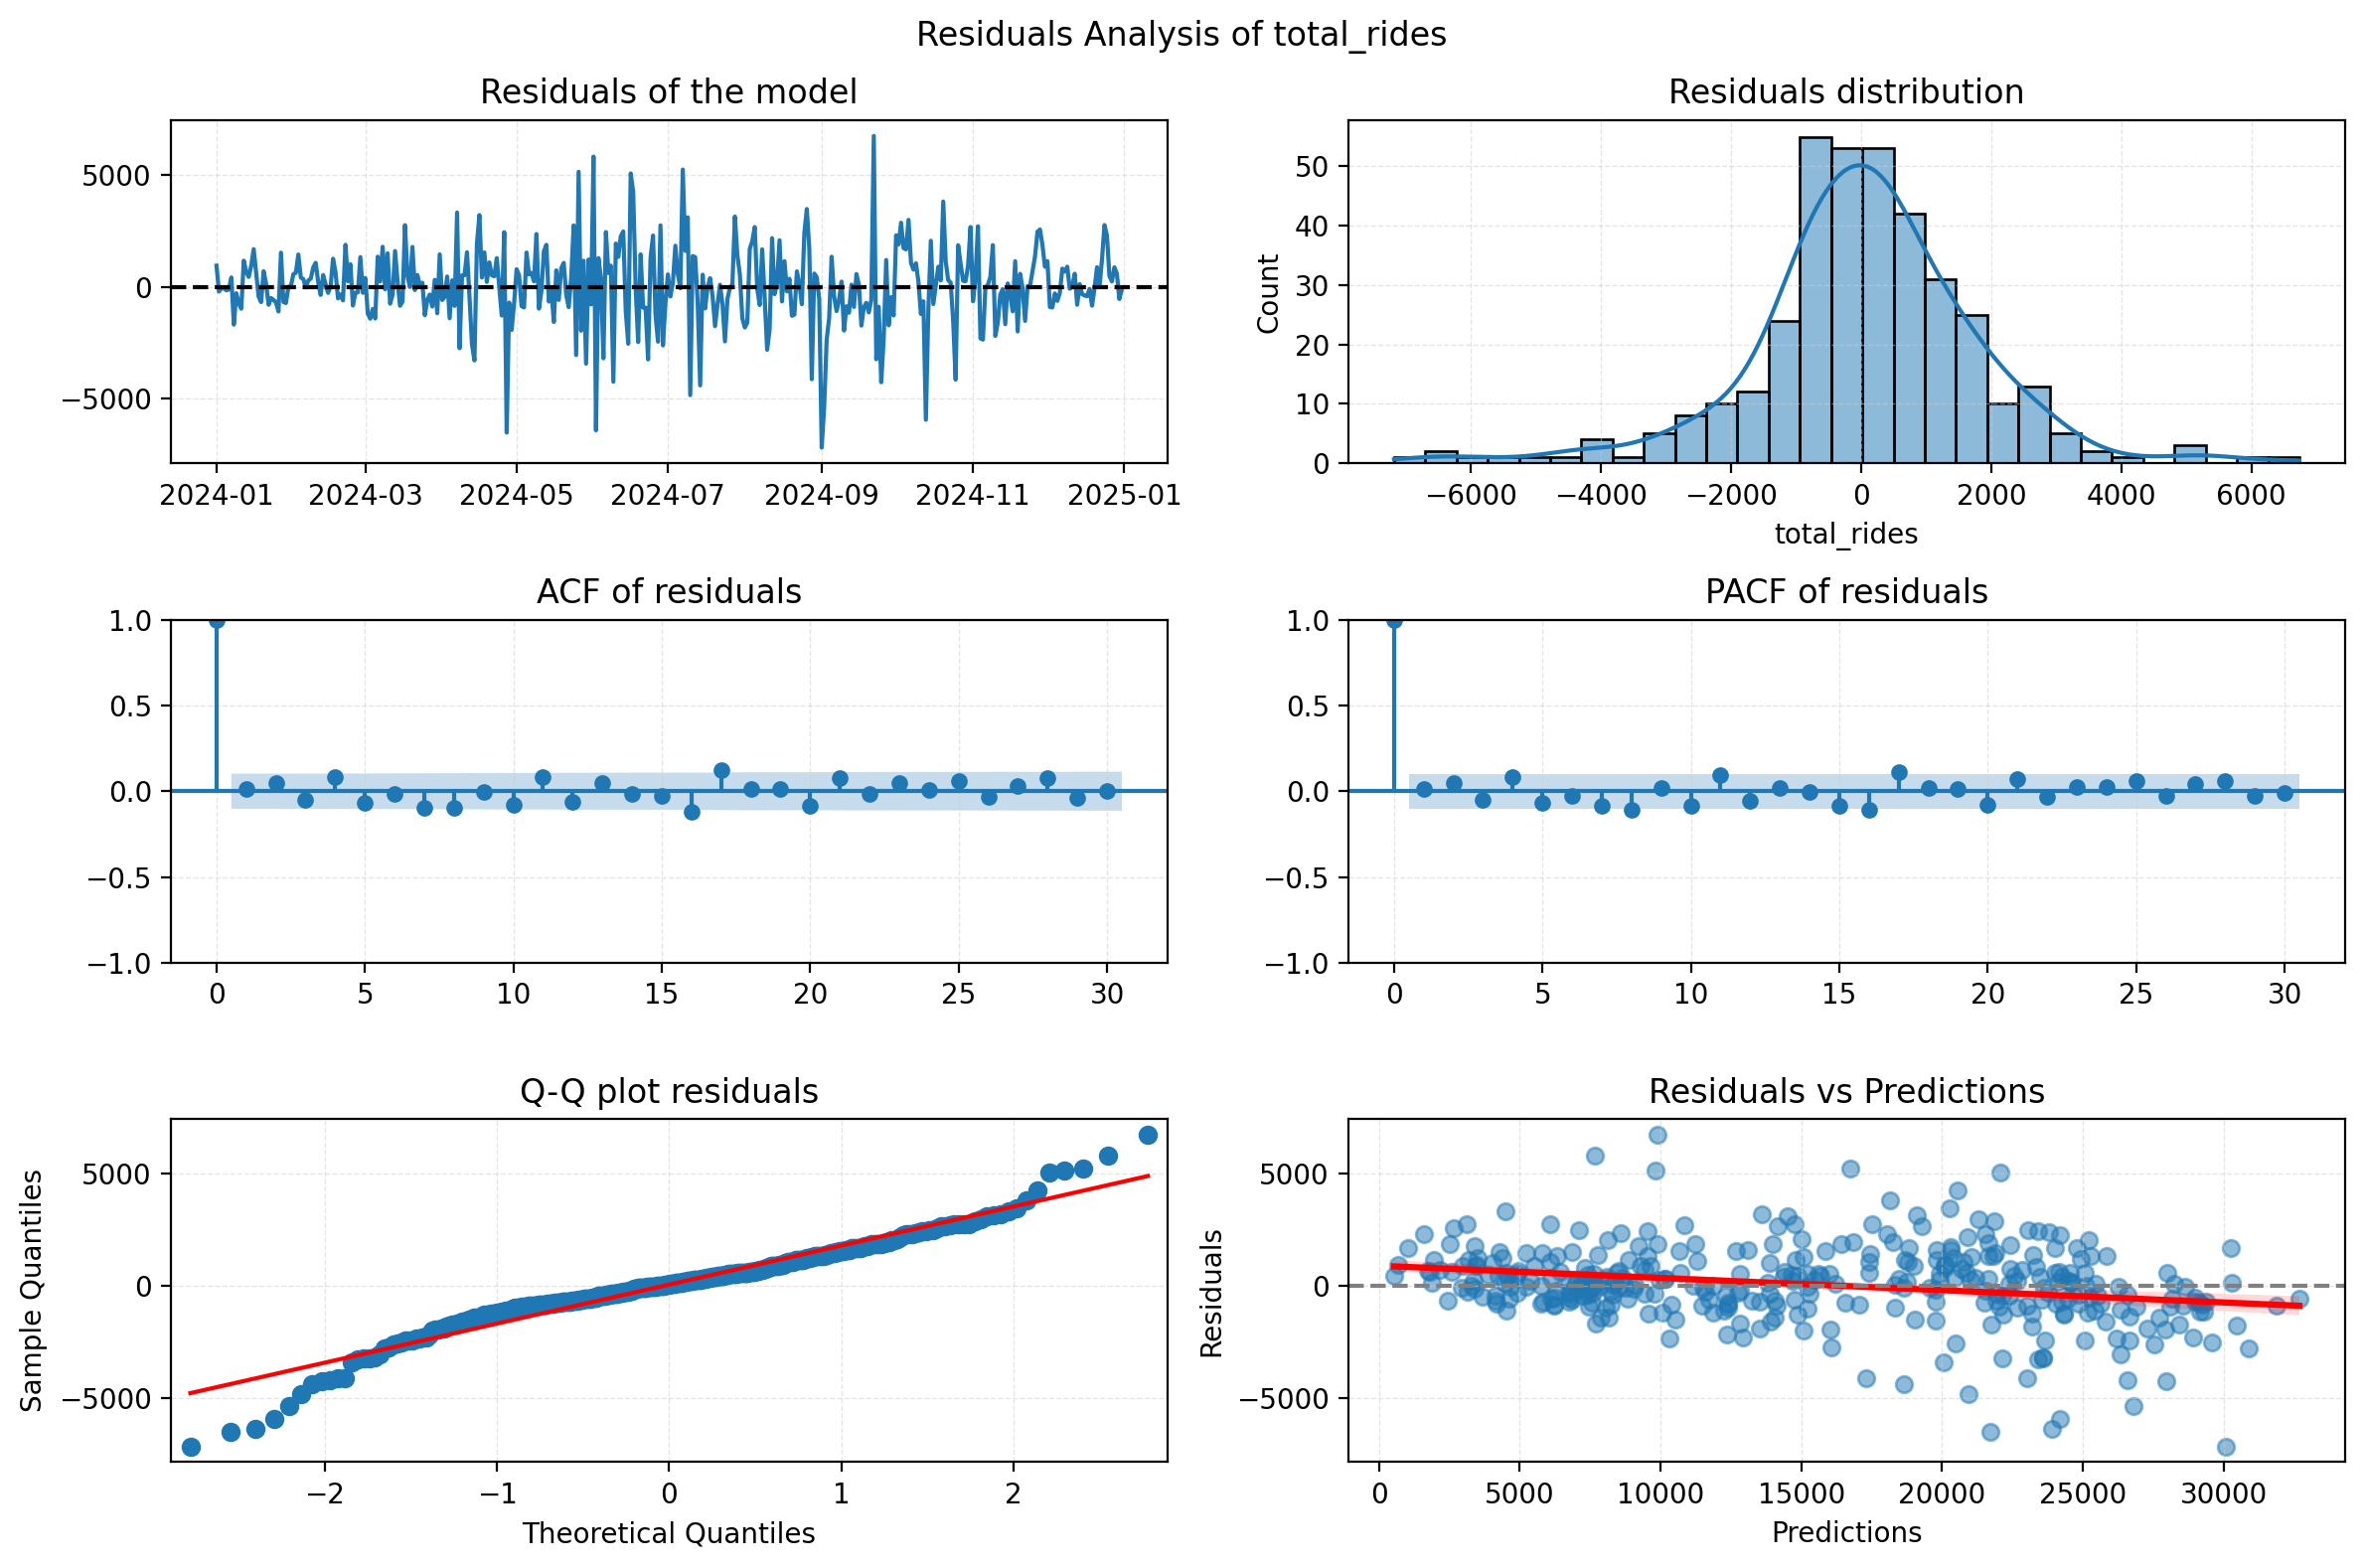


--- Ljung-Box Test ---
    lb_stat  lb_pvalue
10  15.5301     0.1139
Residuals do not show significant autocorrelation

-- Dickey–Fuller test --
ADF Statistic: -18.851513534237025
p-value: 0.0
Time series is stationary

-- KPSS test --
ADF Statistic: 0.0580990704236119
p-value: 0.1
Time series is stationary


In [39]:
check_residuals(bu_total_ensemble_forecast, test["total_rides"], "total_rides")

In [40]:
ensemble_mae_scores['bottom-up']['mae']['total_rides'] = bu_total_ensemble_mae

##### Sub-Total forecasting (Bottom-Up)

In [41]:
bu_ct_ensemble_forecast = cr_ensemble_forecast + ce_ensemble_forecast
bu_mt_ensemble_forecast = mr_ensemble_forecast + me_ensemble_forecast
bu_et_ensemble_forecast = me_ensemble_forecast + ce_ensemble_forecast
bu_rt_ensemble_forecast = cr_ensemble_forecast + mr_ensemble_forecast

bu_ct_ensemble_mae = mean_absolute_error(test['casual_total'], bu_ct_ensemble_forecast)
bu_mt_ensemble_mae = mean_absolute_error(test['member_total'], bu_mt_ensemble_forecast)
bu_et_ensemble_mae = mean_absolute_error(test['electric_total'], bu_et_ensemble_forecast)
bu_rt_ensemble_mae = mean_absolute_error(test['regular_total'], bu_rt_ensemble_forecast)

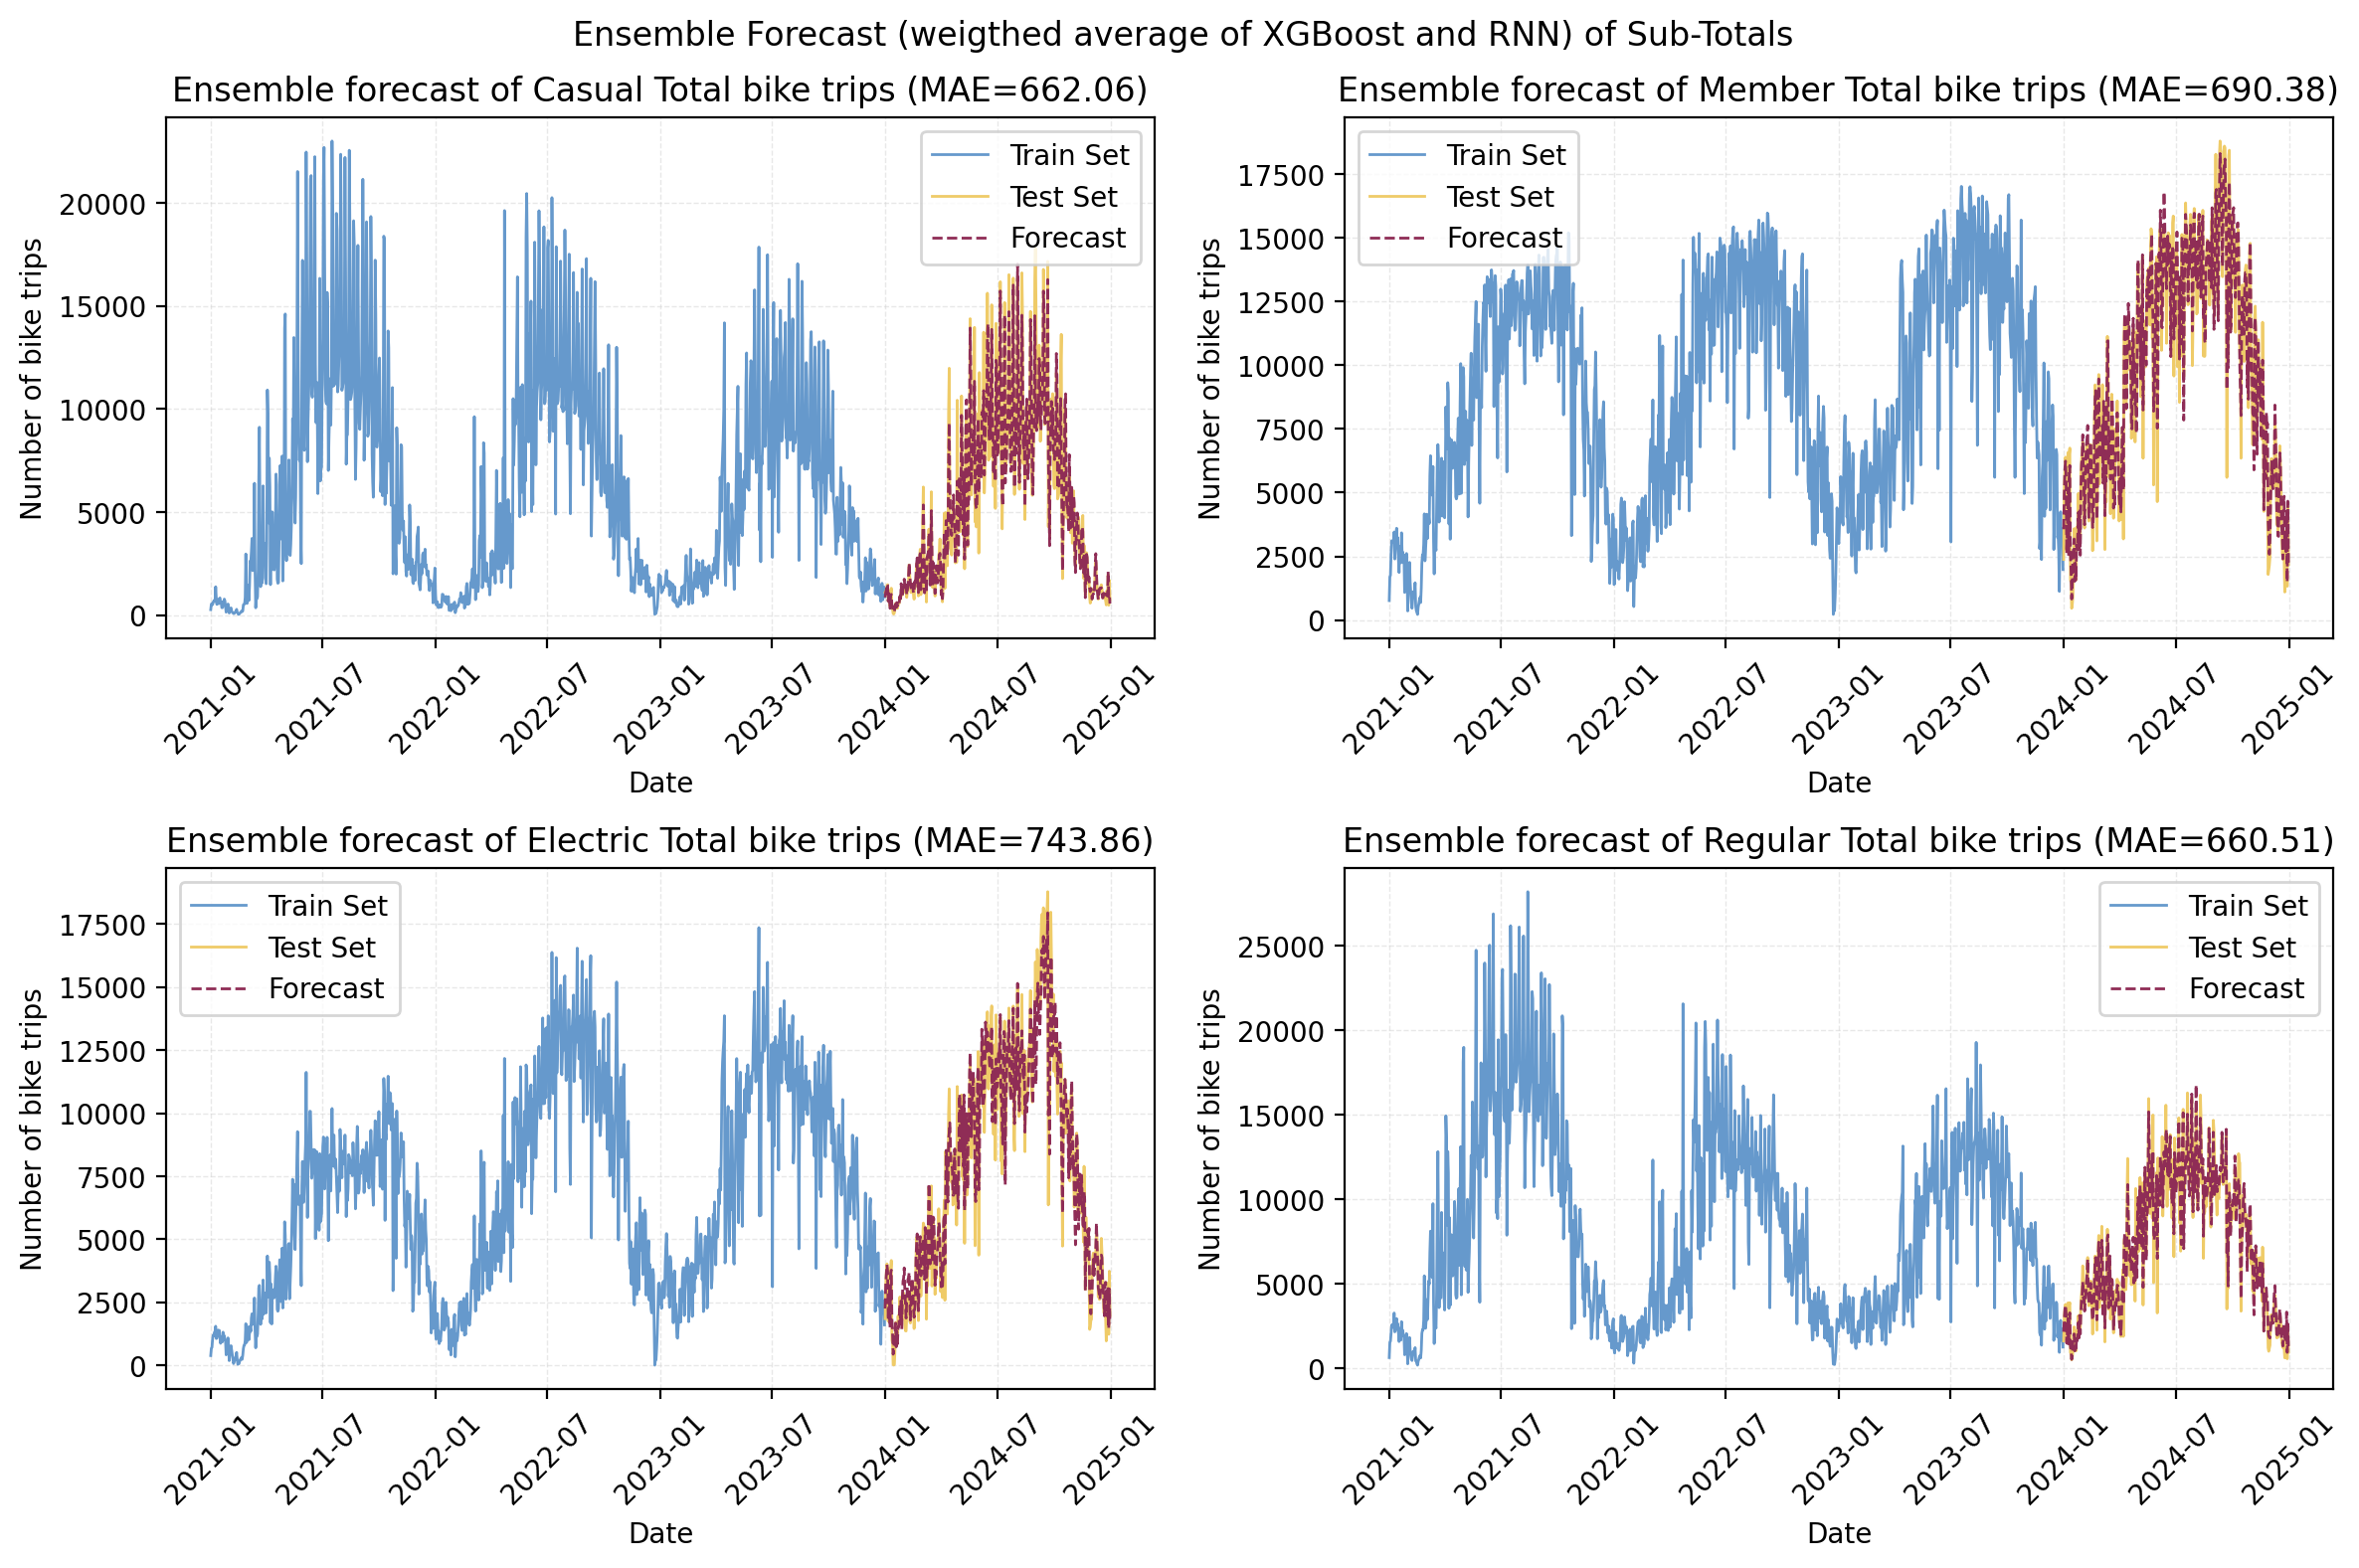

In [42]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8), facecolor='white')

plot_trips(train=train["casual_total"], 
                    test=test["casual_total"],
                    forecast=pd.DataFrame(bu_ct_ensemble_forecast, test.index),
                    title=f"Ensemble forecast of Casual Total bike trips (MAE={bu_ct_ensemble_mae:.2f})",
                    ax=ax[0, 0])

plot_trips(train=train["member_total"], 
                    test=test["member_total"],
                    forecast=pd.DataFrame(bu_mt_ensemble_forecast, test.index),
                    title=f"Ensemble forecast of Member Total bike trips (MAE={bu_mt_ensemble_mae:.2f})",
                    ax=ax[0, 1])

plot_trips(train=train["electric_total"], 
                    test=test["electric_total"],
                    forecast=pd.DataFrame(bu_et_ensemble_forecast, test.index),
                    title=f"Ensemble forecast of Electric Total bike trips (MAE={bu_et_ensemble_mae:.2f})",
                    ax=ax[1, 0])

plot_trips(train=train["regular_total"], 
                    test=test["regular_total"],
                    forecast=pd.DataFrame(bu_rt_ensemble_forecast, test.index),
                    title=f"Ensemble forecast of Regular Total bike trips (MAE={bu_rt_ensemble_mae:.2f})",
                    ax=ax[1, 1])

plt.suptitle("Ensemble Forecast (weigthed average of XGBoost and RNN) of Sub-Totals")
plt.tight_layout()
plt.show()

In [43]:
ensemble_mae_scores['bottom-up']['mae']['casual_total'] = bu_ct_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['member_total'] = bu_mt_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['electric_total'] = bu_et_ensemble_mae
ensemble_mae_scores['bottom-up']['mae']['regular_total'] = bu_rt_ensemble_mae

In [44]:
ensemble_mae_scores_df = pd.DataFrame({method: values['mae'] for method, values in ensemble_mae_scores.items()})
ensemble_mae_scores_df.index.name= "MAE"
ensemble_mae_scores_df

,bottom-up,top-down
MAE,,
total_rides,"1,237.7575","1,248.9963"
regular_total,660.5138,"1,323.2102"
electric_total,743.8637,"1,311.8645"
casual_total,662.0552,"1,613.8447"
member_total,690.3836,"1,592.3876"
casual_regular_bike,359.3054,"1,120.8067"
member_regular_bike,383.3503,922.0587
casual_electric_bike,376.3017,721.7883
member_electric_bike,420.3737,"1,185.7460"


### Ensembling Summary

In [45]:
best_maes = {"ensemble models": 
                    {
                        "total_rides": 'SUM["C/R", "M/R", "C/E", "M/E"]',
                        "regular_total": 'SUM["C/R", "M/R"]',
                        "electric_total": 'SUM["C/E", "M/E"]',
                        "casual_total": 'SUM["C/R", "C/E"]',
                        "member_total": 'SUM["M/R", "M/E"]',
                        "casual_regular_bike": cr_ensemble_models,
                        "member_regular_bike": mr_ensemble_models,
                        "casual_electric_bike": ce_ensemble_models,
                        "member_electric_bike": me_ensemble_models
                    },
             "ensemble mae": 
                    {
                        "total_rides": bu_total_ensemble_mae,
                        "regular_total": bu_rt_ensemble_mae,
                        "electric_total": bu_et_ensemble_mae,
                        "casual_total": bu_ct_ensemble_mae,
                        "member_total": bu_mt_ensemble_mae,
                        "casual_regular_bike": cr_ensemble_mae,
                        "member_regular_bike": mr_ensemble_mae,
                        "casual_electric_bike": ce_ensemble_mae,
                        "member_electric_bike": me_ensemble_mae
                    }}      

In [46]:
pd.DataFrame({"XGBoost MAE": xgboost_maes,
              "RNN/LSTM MAE": rnn_maes, 
              "HARIMAX MAE": harimax_maes, 
              "Ensembled Models": best_maes["ensemble models"],
              "Ensembled MAE": best_maes["ensemble mae"]})

,XGBoost MAE,RNN/LSTM MAE,HARIMAX MAE,Ensembled Models,Ensembled MAE
casual_regular_bike,408.0877,494.4156,406.5967,"(xgboost, rnn, harimax)",359.3054
casual_electric_bike,427.7171,498.8242,388.3748,"(xgboost, harimax)",376.3017
member_regular_bike,454.8271,458.1068,407.0505,"(xgboost, rnn, harimax)",383.3503
member_electric_bike,562.4547,520.0868,423.8279,"(rnn, harimax)",420.3737
casual_total,697.8636,903.7900,744.2950,"SUM[""C/R"", ""C/E""]",662.0552
member_total,842.9306,797.7675,740.9927,"SUM[""M/R"", ""M/E""]",690.3836
electric_total,907.1503,953.5711,761.1018,"SUM[""C/E"", ""M/E""]",743.8637
regular_total,746.3969,782.2802,745.0698,"SUM[""C/R"", ""M/R""]",660.5138
total_rides,"1,353.5334","1,524.6052","1,372.9184","SUM[""C/R"", ""M/R"", ""C/E"", ""M/E""]","1,237.7575"


### Save results <a name='save-data'></a>

In [47]:
"""
Dump Structure

{
    # Bottom-level entry
    "target_name": {
        "level": "bottom",
        "models": tuple,
        "mea": float,
        "forecast": np.ndarray,
        "weights": [...]
    },

    # Cross-level or Top-level
    "target_name": {
        "level": "cross|top",
        "sum": [...],                      # Bottom-level keys to sum forecasts from
        "mae": float,
        "forecast": np.ndarray
    }
}


"""
ensemble_models_dump = {
    "ensemble":{
        # bottom-level
        "casual_regular_bike": {
            "level": "bottom",
            "models": cr_ensemble_models,
            "mea": cr_ensemble_mae,
            "forecast": cr_ensemble_forecast,
            "weights": dict(zip(cr_ensemble_models, cr_ensemble_weights))
        },
        "casual_electric_bike": {
            "level": "bottom",
            "models": ce_ensemble_models,
            "mea": ce_ensemble_mae,
            "forecast": ce_ensemble_forecast,
            "weights": dict(zip(ce_ensemble_models, ce_ensemble_weights))
        },
        "member_regular_bike": {
            "level": "bottom",
            "models": mr_ensemble_models,
            "mea": mr_ensemble_mae,
            "forecast": mr_ensemble_forecast,
            "weights": dict(zip(mr_ensemble_models, mr_ensemble_weights))
        },
        "member_electric_bike": {
            "level": "bottom",
            "models": me_ensemble_models,
            "mea": me_ensemble_mae,
            "forecast": me_ensemble_forecast,
            "weights": dict(zip(me_ensemble_models, me_ensemble_weights))
        },
        # cross level
        "casual_total":{
            "level": "cross",
            "sum": ["casual_regular_bike", "casual_electric_bike"],
            "mae": bu_ct_ensemble_mae,
            "forecast": bu_ct_ensemble_forecast
        },
        "member_total":{
            "level": "cross",
            "sum": ["member_regular_bike", "member_electric_bike"],
            "mae": bu_mt_ensemble_mae,
            "forecast": bu_mt_ensemble_forecast
        },
        "electric_total":{
            "level": "cross",
            "sum": ["member_electric_bike", "casual_electric_bike"],
            "mae": bu_et_ensemble_mae,
            "forecast": bu_et_ensemble_forecast
        },
        "regular_total":{
            "level": "cross",
            "sum": ["member_regular_bike", "casual_regular_bike"],
            "mae": bu_rt_ensemble_mae,
            "forecast": bu_rt_ensemble_forecast
        },
        # top-level
        "total_rides":{
            "level": "top",
            "sum": ["member_regular_bike", "casual_regular_bike", "member_electric_bike", "casual_electric_bike"],
            "mae": bu_total_ensemble_mae,
            "forecast": bu_total_ensemble_forecast
        },
    }
}

In [48]:
dirname = "../03_models/04_ensemble/"
with open(dirname + "ensemble_models_dump.pkl", "wb") as f:
    pickle.dump(ensemble_models_dump, f)


---
\
[__<< Feature Engineering__](./04_Divvy_feature_engineering.ipynb) | [__Home__](../README.md)
\
\
Divvy: Bike Sharing Forecast, _May 2025_